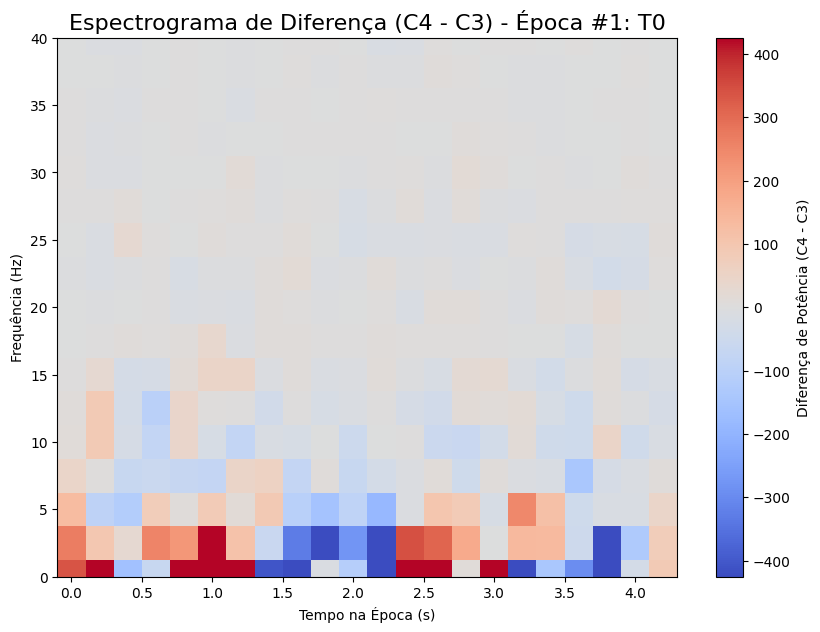

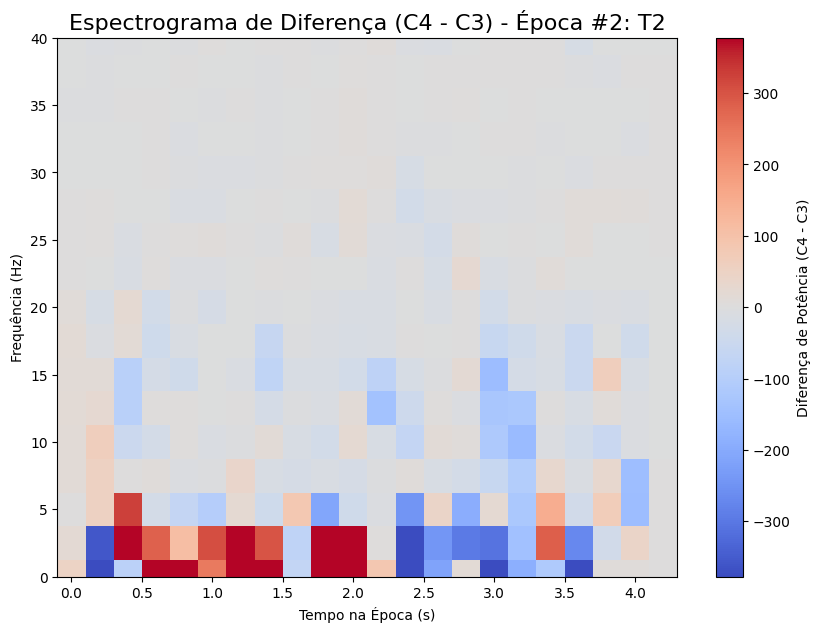

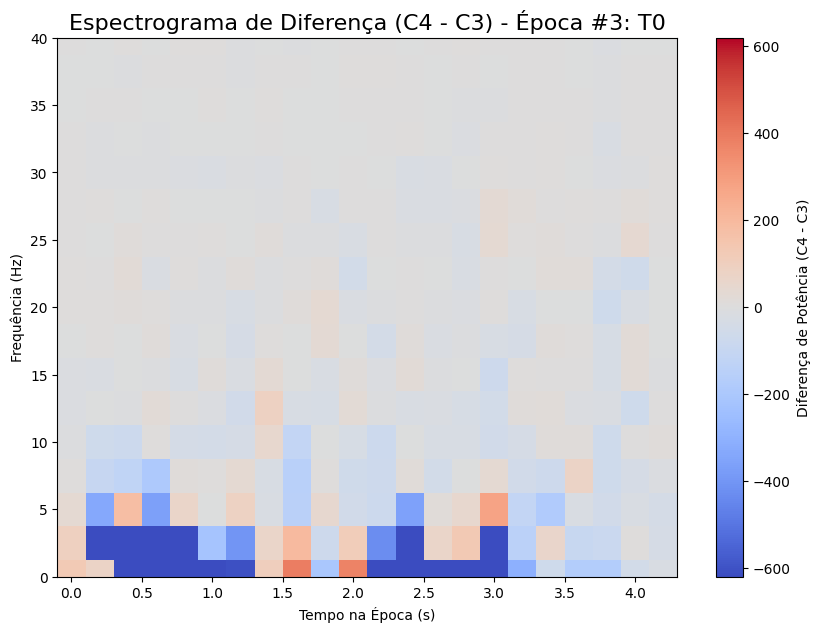

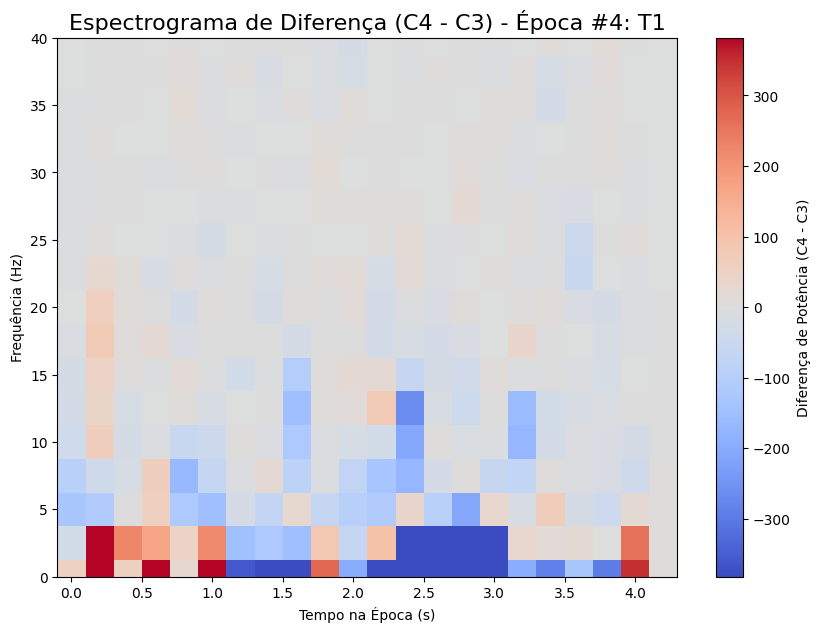

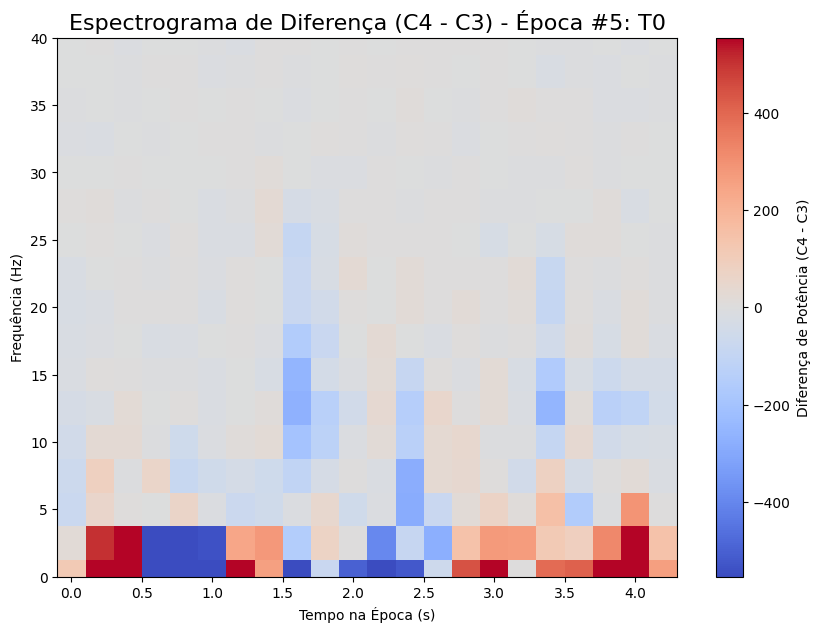

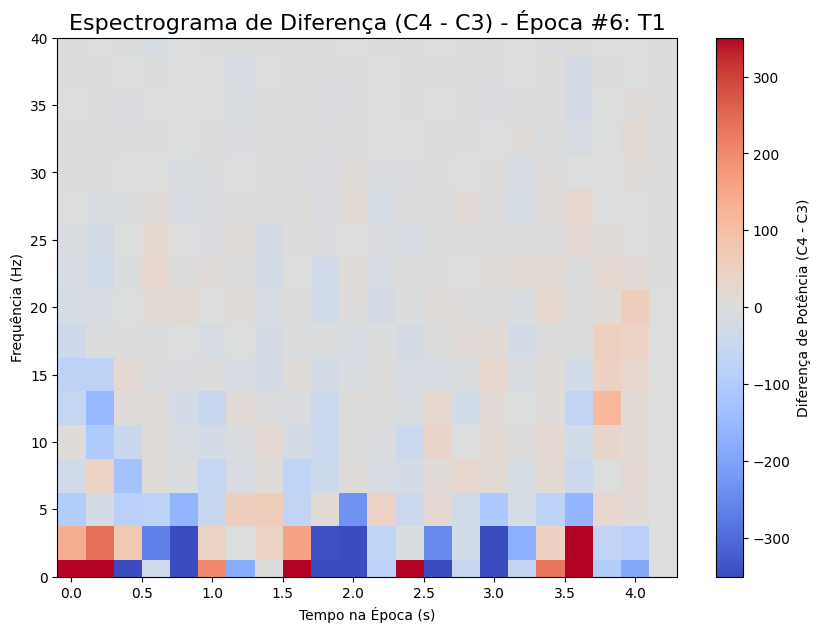

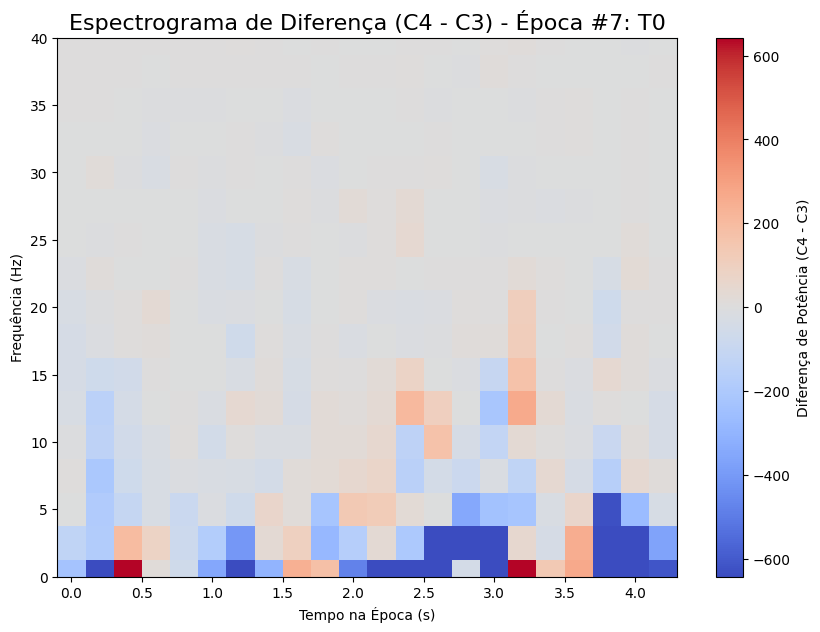

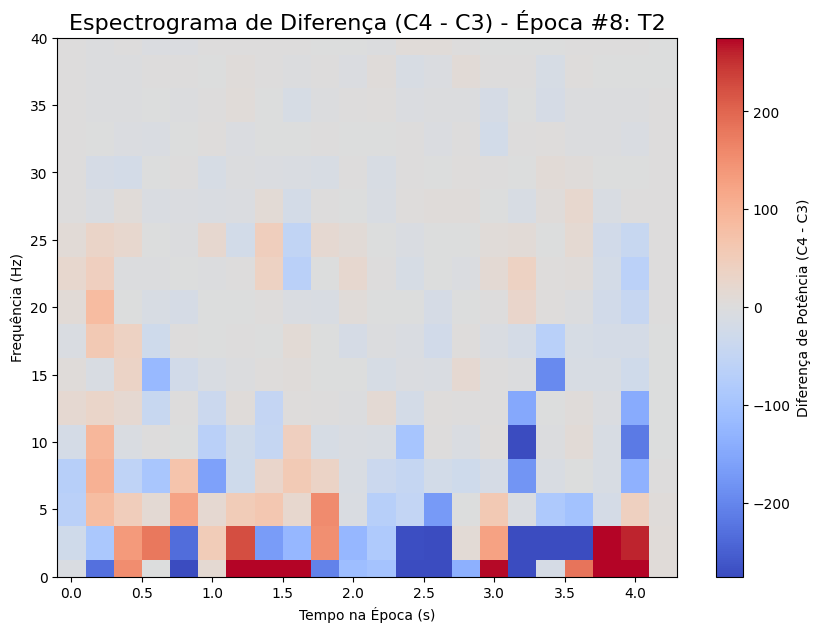

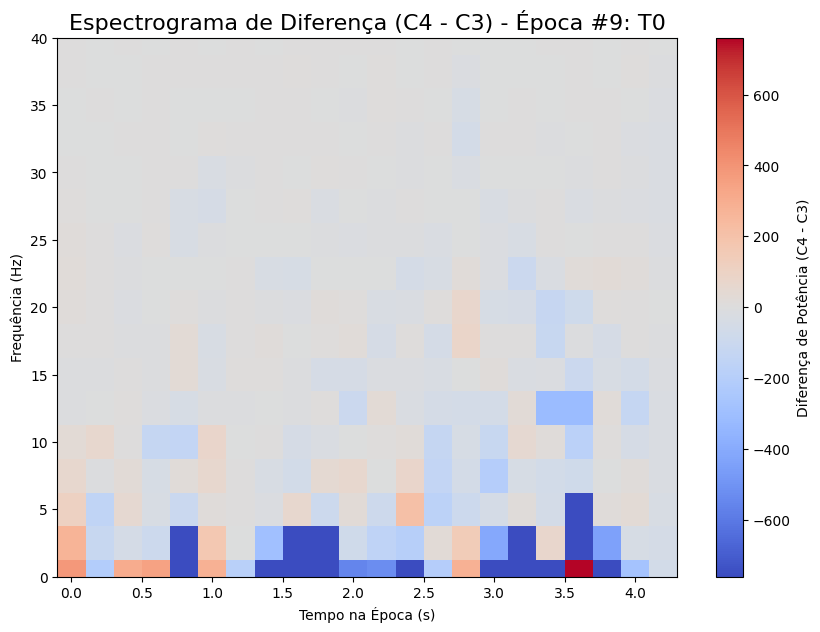

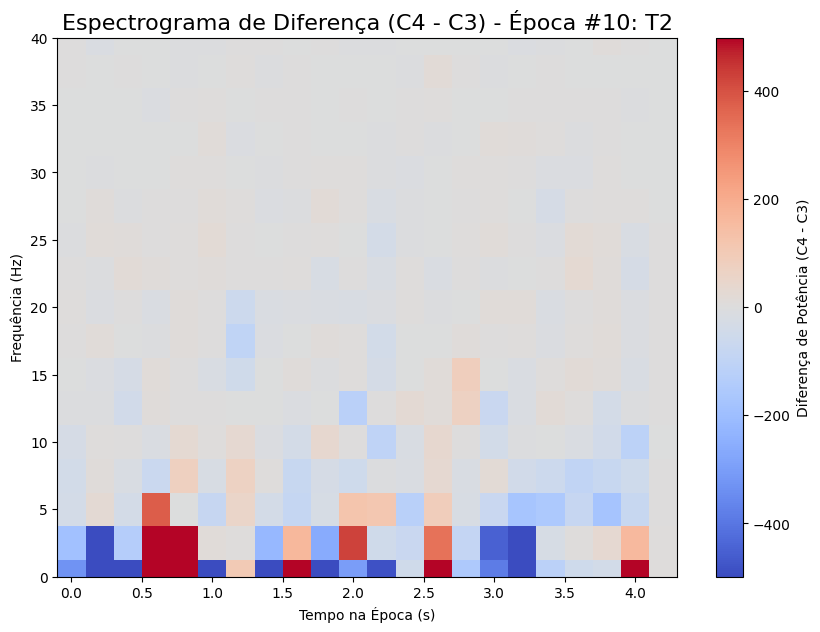

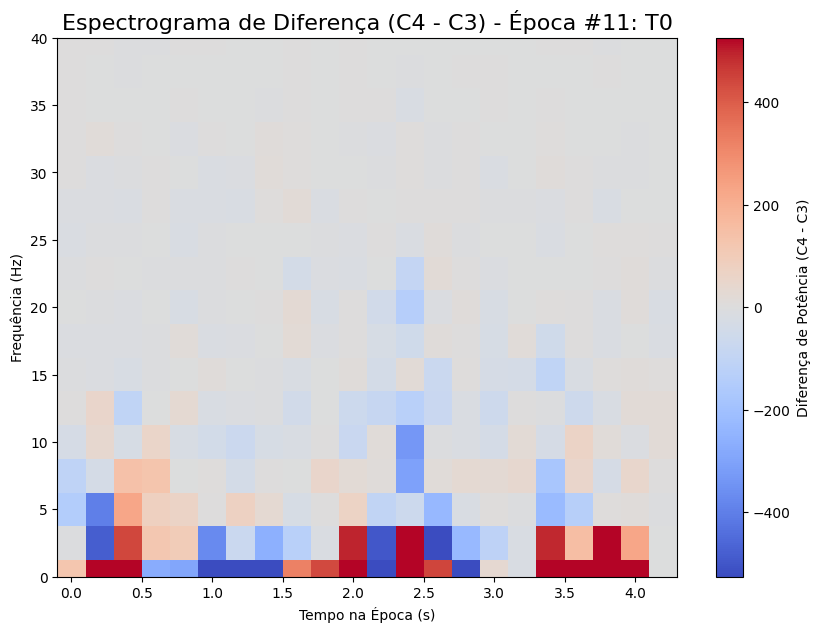

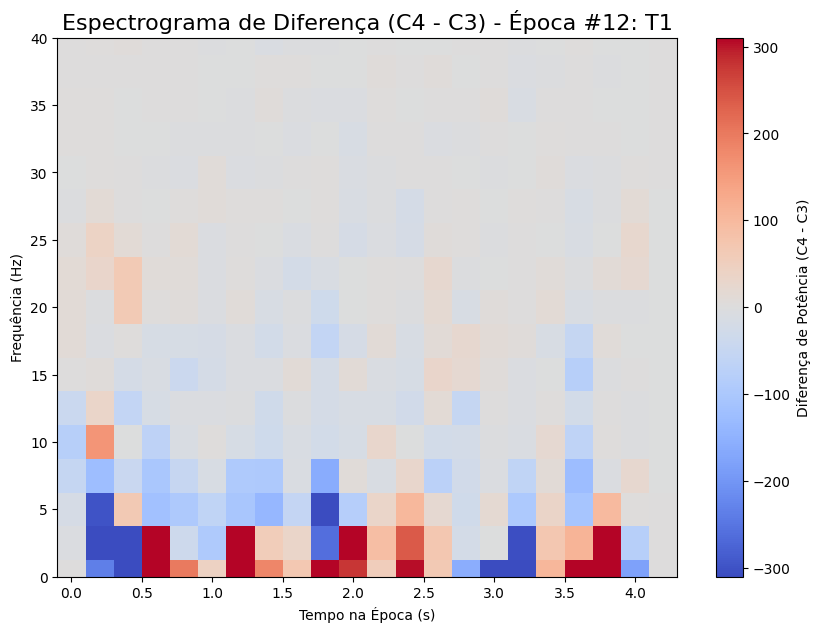

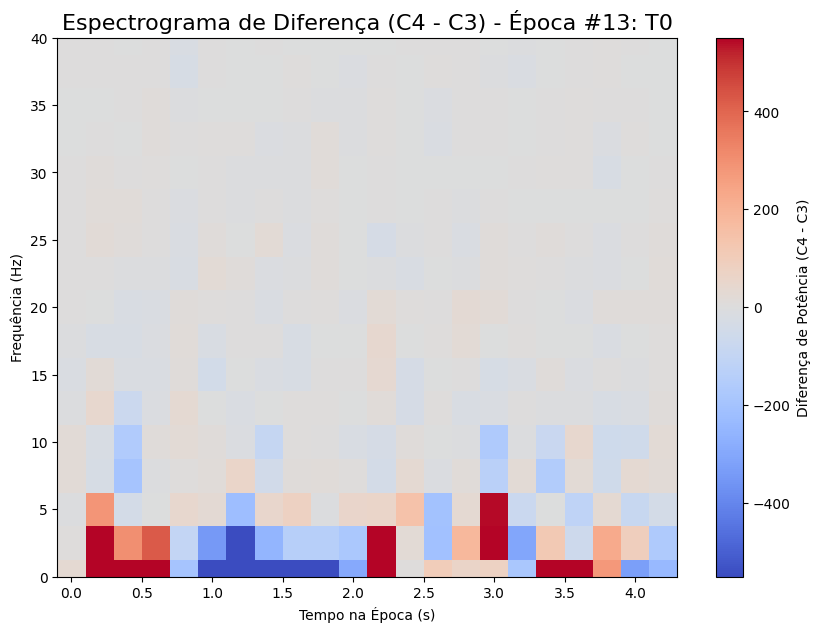

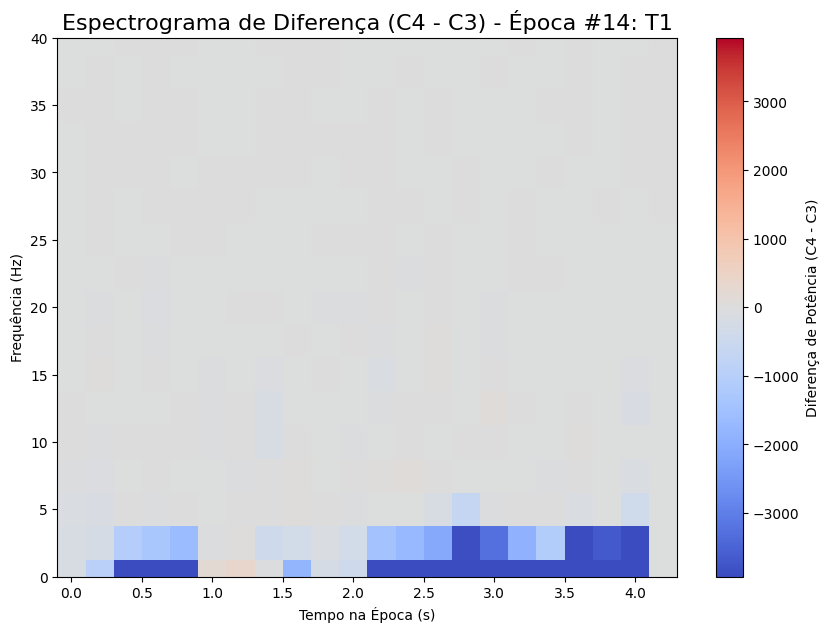

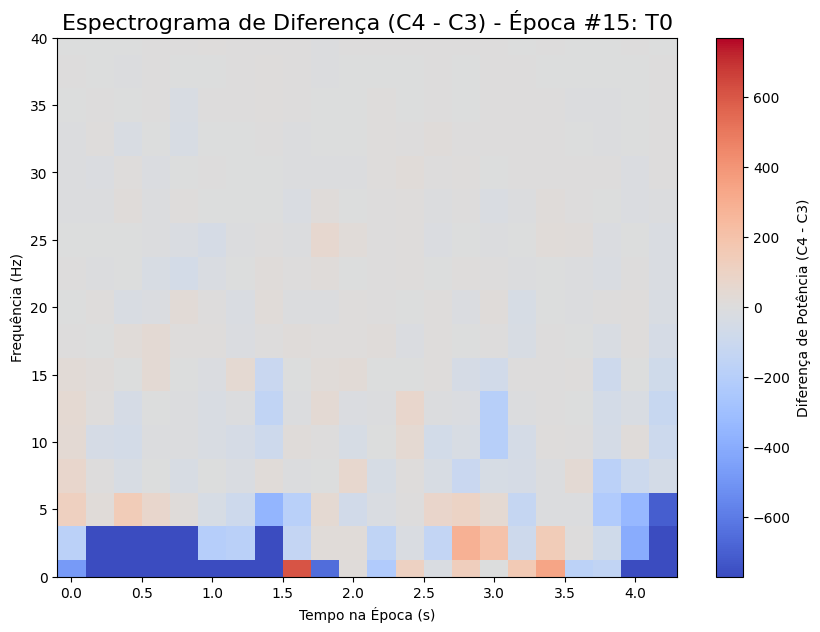

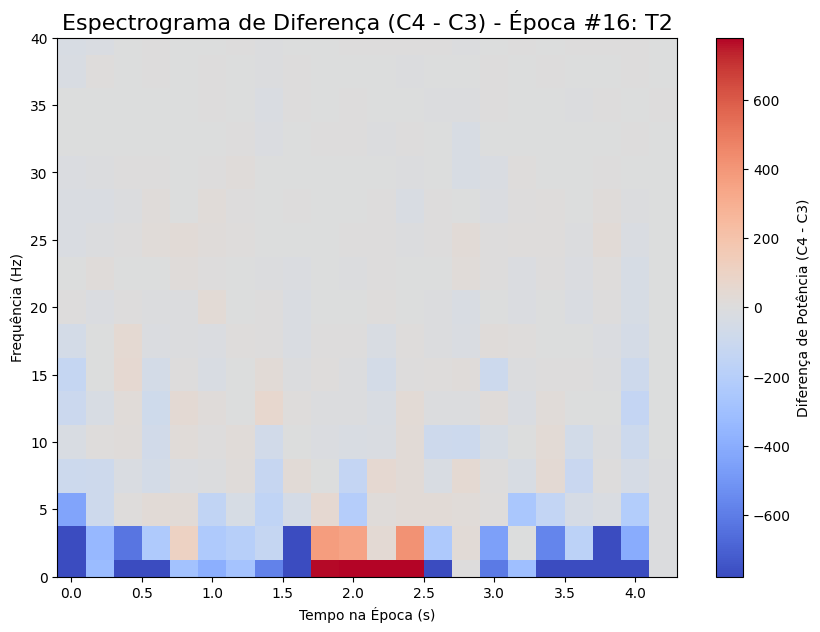

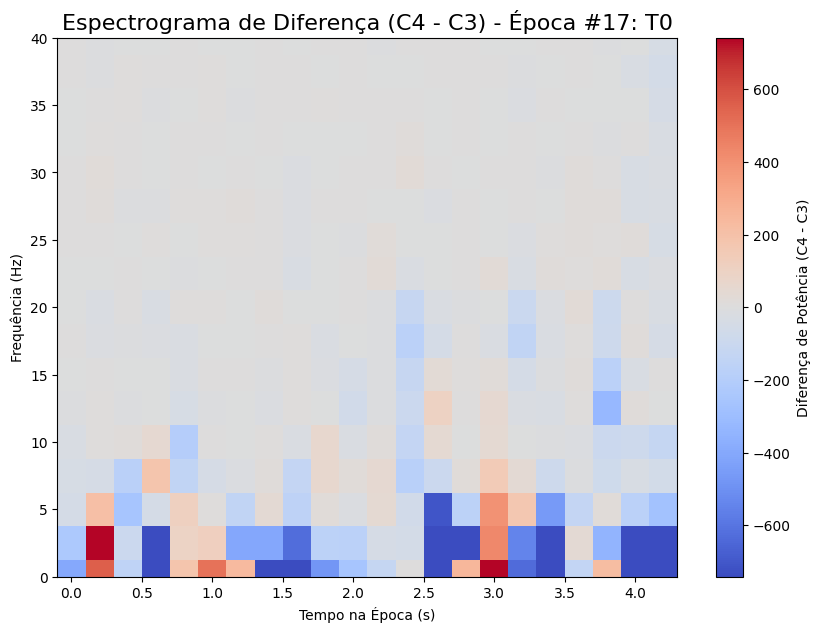

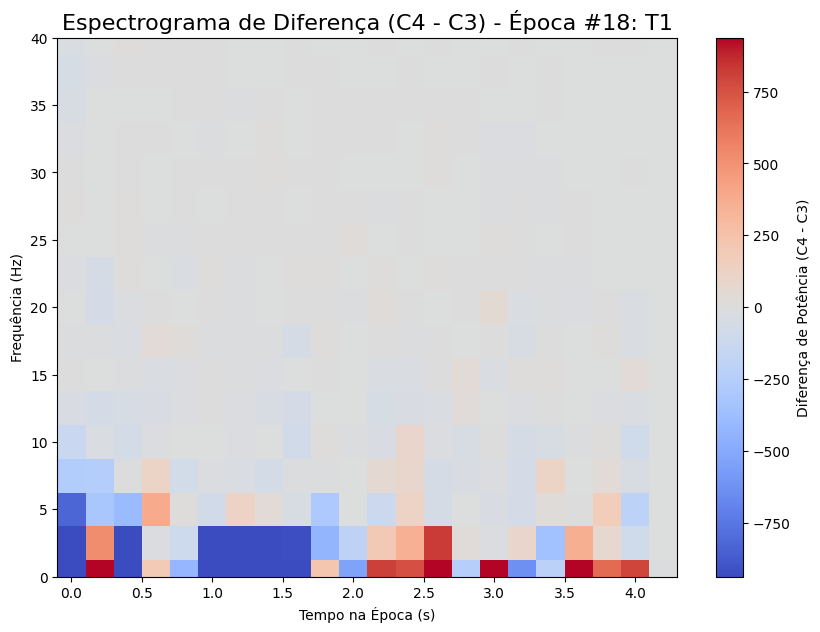

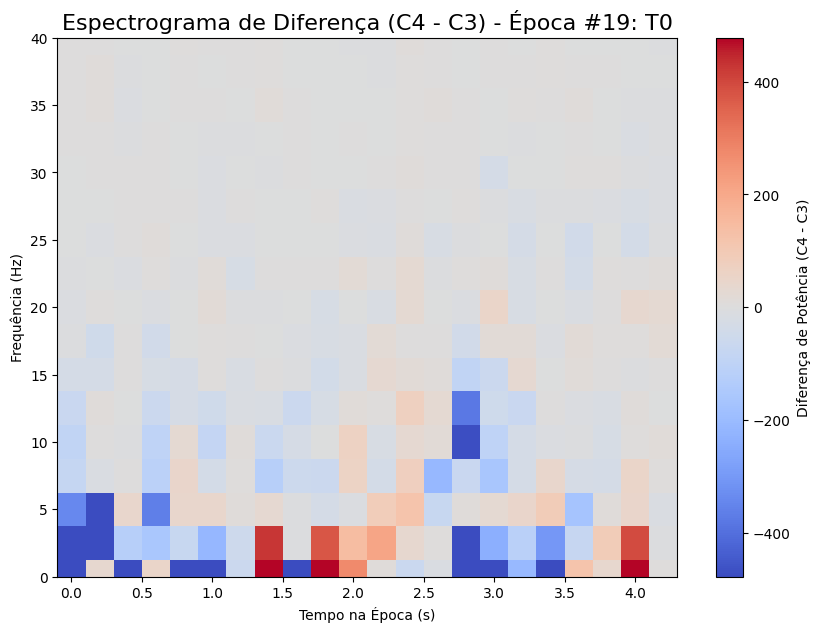

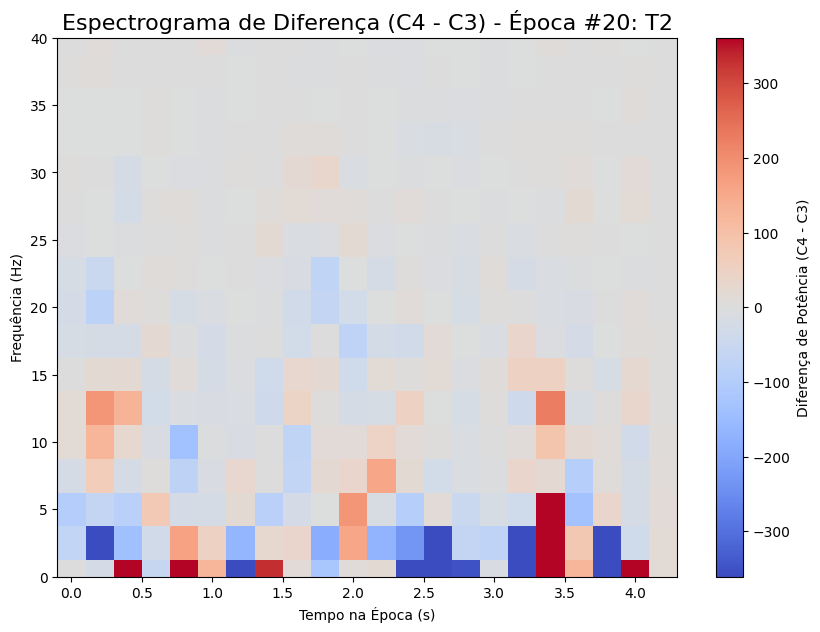

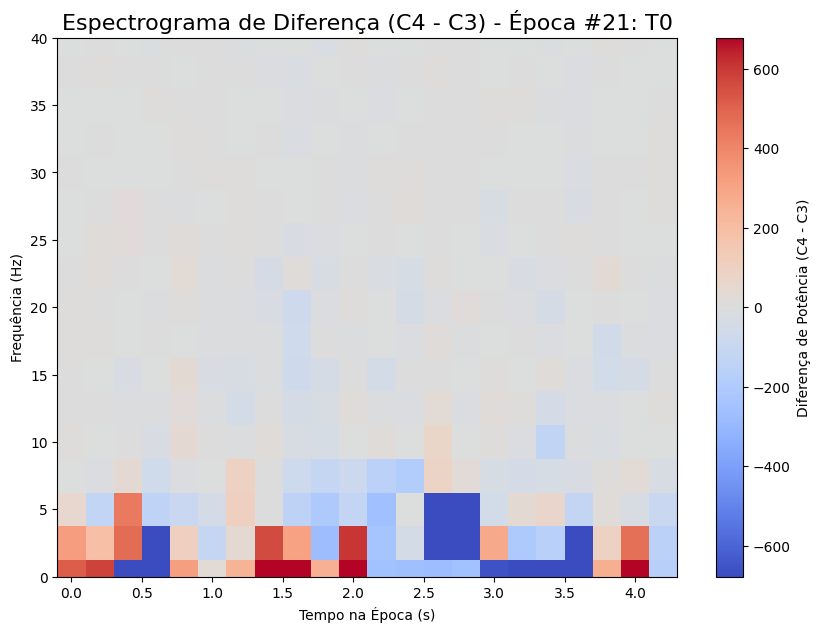

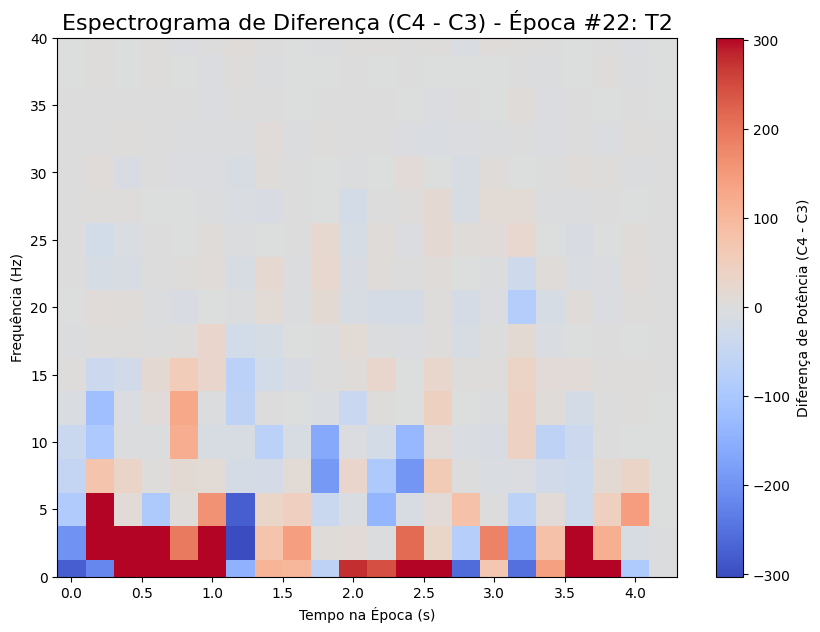

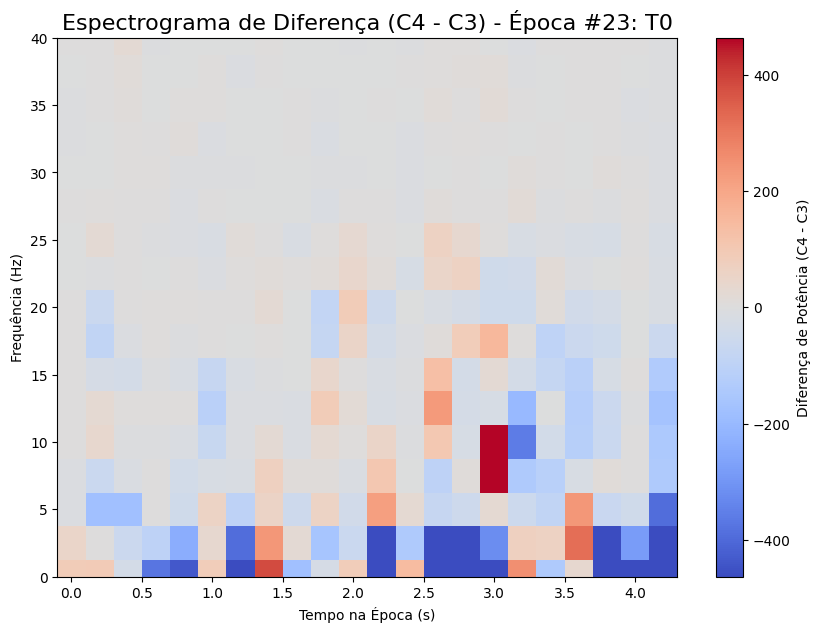

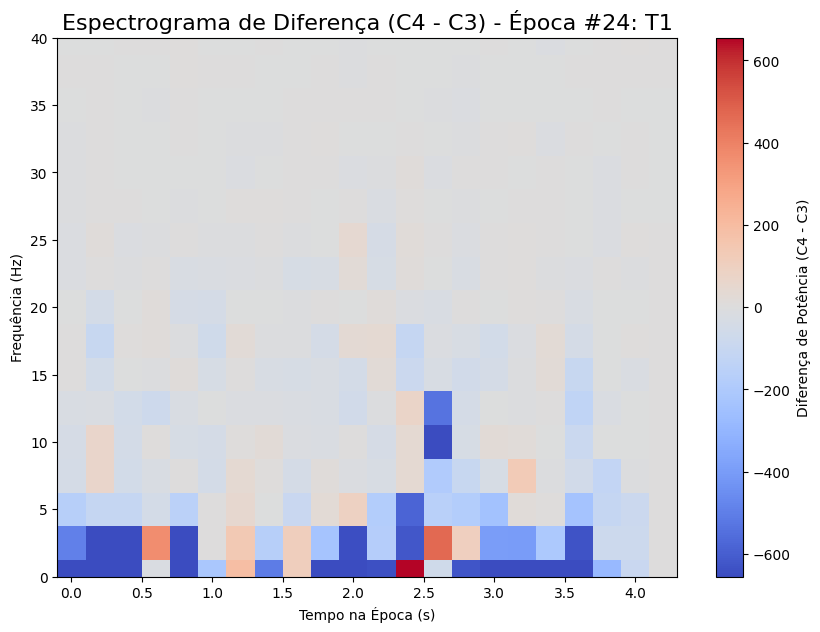

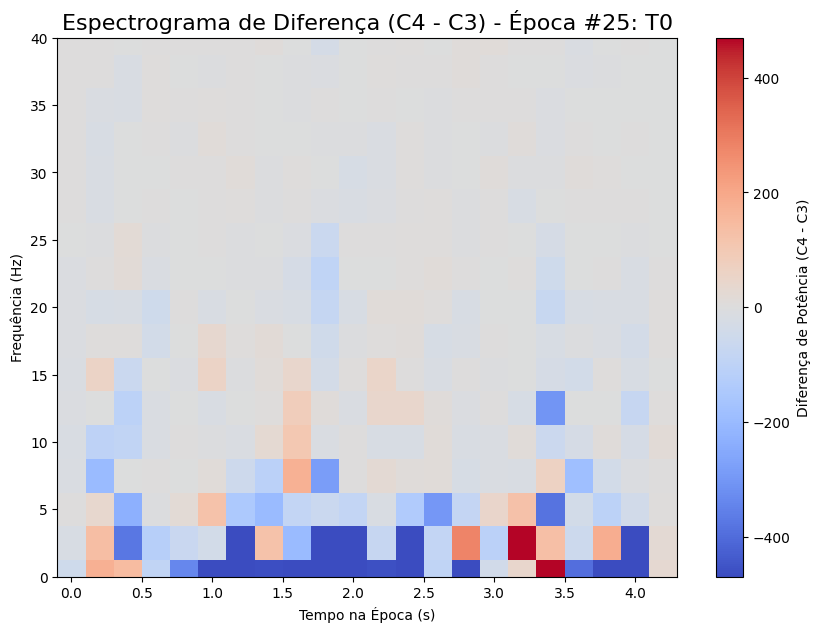

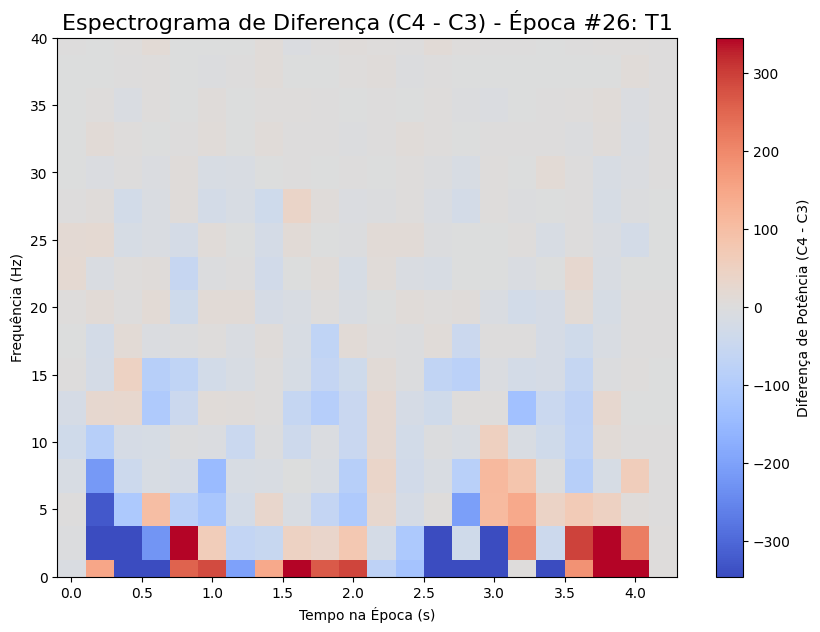

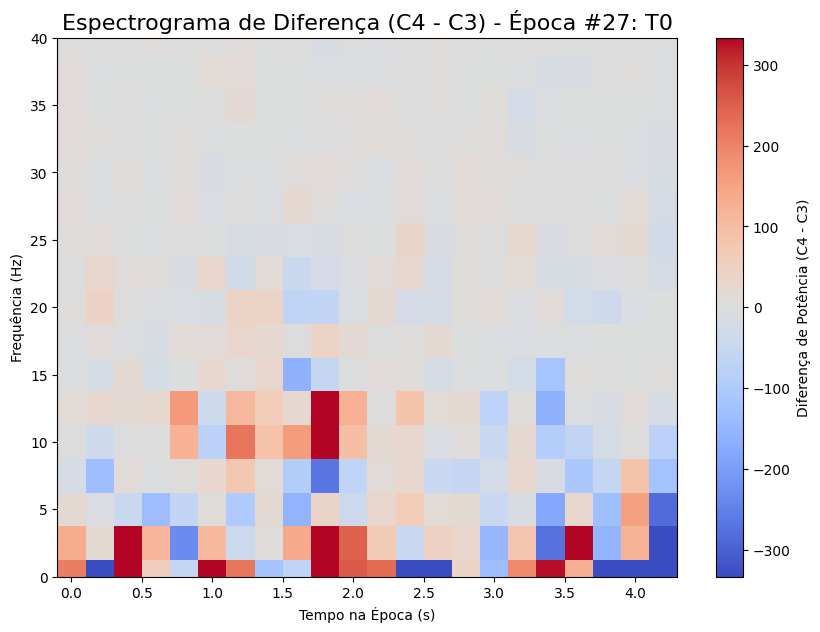

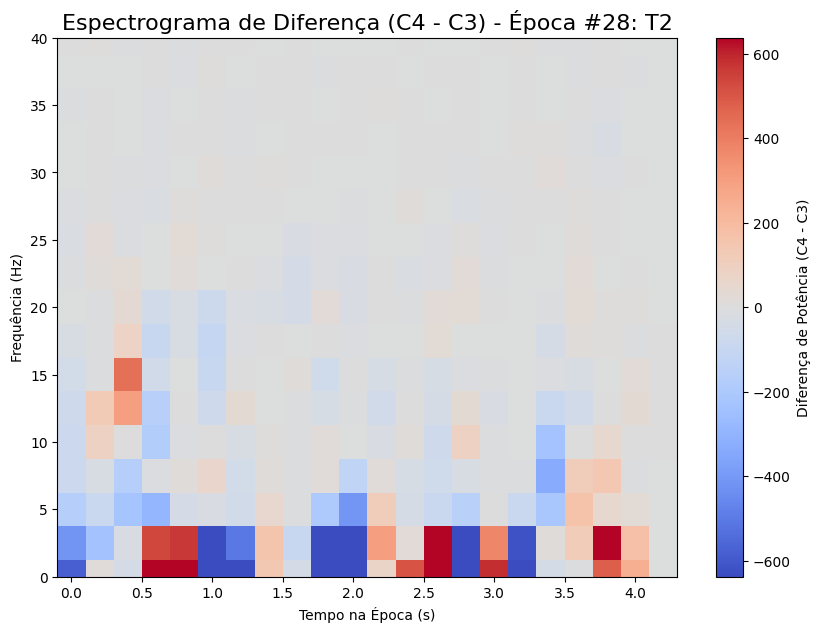

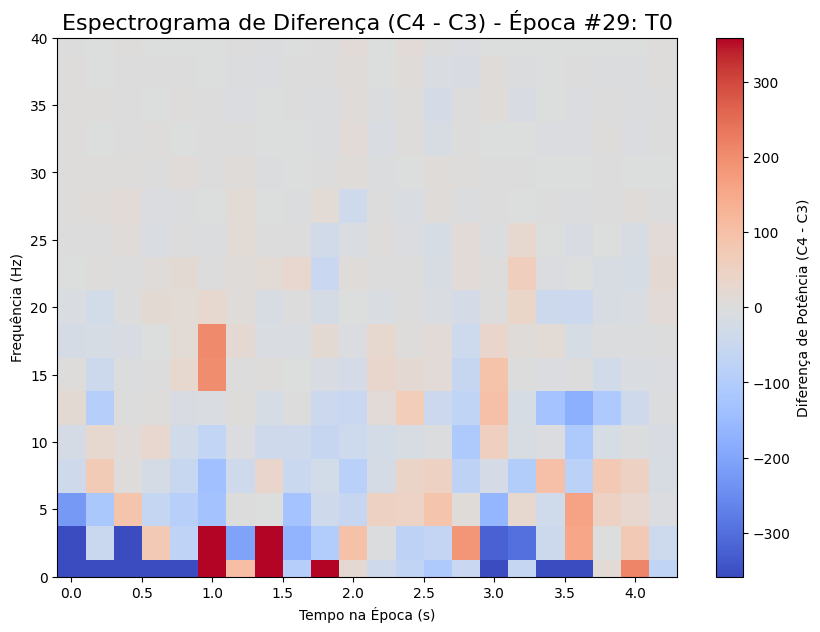

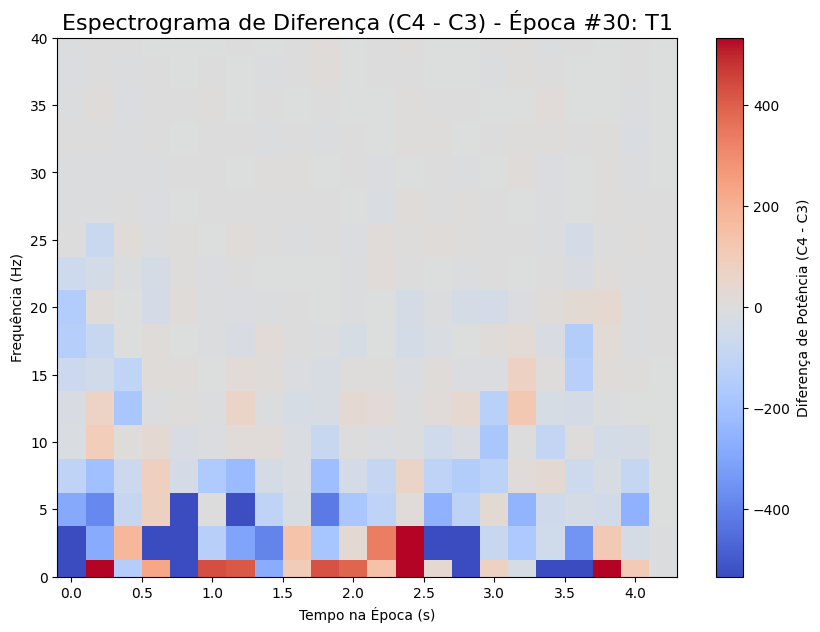

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.signal import stft
from pyedflib import highlevel
import os

# ... (carregamento do arquivo e outras configurações como no código anterior) ...
FILE_PATH = os.path.join('data', 'physionet_data', 'S001', 'S001R03.edf')
signals, signal_headers, header = highlevel.read_edf(FILE_PATH)
annotations = header['annotations']
fs = signal_headers[0]['sample_frequency']
channel_names = [h['label'] for h in signal_headers]
c3_idx = channel_names.index('C3..')
c4_idx = channel_names.index('C4..')
signal_c3 = signals[c3_idx, :]
signal_c4 = signals[c4_idx, :]

# Parâmetros (vamos usar 400ms como exemplo)
nperseg = int(0.4 * fs)
noverlap = nperseg // 2

for i, (onset, duration, description) in enumerate(annotations):
    start_sample, end_sample = int(onset * fs), int((onset + duration) * fs)
    if end_sample > len(signal_c3): continue

    epoch_c3, epoch_c4 = signal_c3[start_sample:end_sample], signal_c4[start_sample:end_sample]
    
    f, t, Zxx_c3 = stft(epoch_c3, fs=fs, nperseg=nperseg, noverlap=noverlap)
    _, _, Zxx_c4 = stft(epoch_c4, fs=fs, nperseg=nperseg, noverlap=noverlap)
    
    # Calcular a potência e a diferença de potência
    power_c3 = np.abs(Zxx_c3)**2
    power_c4 = np.abs(Zxx_c4)**2
    power_difference = power_c4 - power_c3

    # Plotar o espectrograma de DIFERENÇA
    plt.figure(figsize=(10, 7))
    
    # Usar um colormap divergente como 'coolwarm' para ver valores positivos (quente) e negativos (frio)
    vmax = np.percentile(np.abs(power_difference), 98) # Limita a escala de cor para melhor visualização
    plt.pcolormesh(t, f, power_difference, cmap='coolwarm', vmin=-vmax, vmax=vmax)
    
    plt.title(f'Espectrograma de Diferença (C4 - C3) - Época #{i+1}: {description}', fontsize=16)
    plt.ylabel('Frequência (Hz)')
    plt.xlabel('Tempo na Época (s)')
    plt.ylim(0, 40)
    plt.colorbar(label='Diferença de Potência (C4 - C3)')
    plt.show()

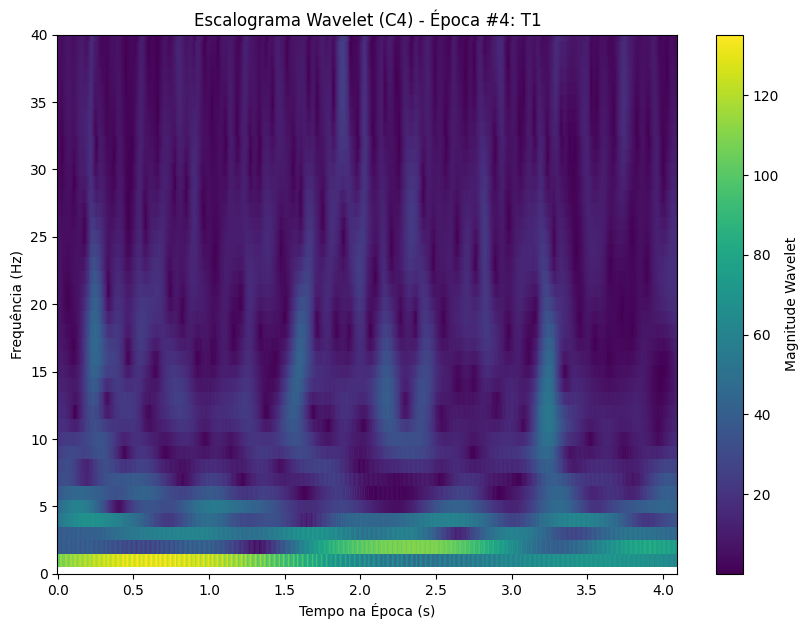

In [5]:
import pywt
# ... (mesmo código de carregamento do arquivo) ...

# Definir as frequências de interesse e a wavelet
frequencies = np.arange(1, 41) # 1 a 40 Hz
wavelet_name = 'cmor1.5-1.0' # Complex Morlet wavelet

# A CWT precisa de uma escala para cada frequência
scales = pywt.frequency2scale(wavelet_name, frequencies / fs)

for i, (onset, duration, description) in enumerate(annotations):
    if description != 'T1': continue # Plotar apenas um exemplo de T1 para não poluir

    start_sample, end_sample = int(onset * fs), int((onset + duration) * fs)
    if end_sample > len(signal_c4): continue

    # Aplicar a CWT no canal C4 para a tarefa de mão esquerda
    epoch_c4 = signal_c4[start_sample:end_sample]
    coeffs, freqs = pywt.cwt(epoch_c4, scales, wavelet_name, sampling_period=1/fs)

    plt.figure(figsize=(10, 7))
    plt.pcolormesh(np.arange(len(epoch_c4)) / fs, freqs, np.abs(coeffs), cmap='viridis')
    plt.title(f'Escalograma Wavelet (C4) - Época #{i+1}: {description}')
    plt.ylabel('Frequência (Hz)')
    plt.xlabel('Tempo na Época (s)')
    plt.ylim(0, 40)
    plt.colorbar(label='Magnitude Wavelet')
    plt.show()
    break # Sair após o primeiro exemplo

Fase 1: Calculando a linha de base média a partir das épocas T0...


Processando T0: 100%|██████████| 30/30 [00:00<00:00, 7502.33it/s]

Linha de base calculada com sucesso.

Fase 2: Calculando e plotando mapas de ERD/ERS% para épocas T1 e T2...



C:\Users\luize\AppData\Local\Temp\ipykernel_16540\3547213581.py:117: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout(rect=[0, 0, 1, 0.95])


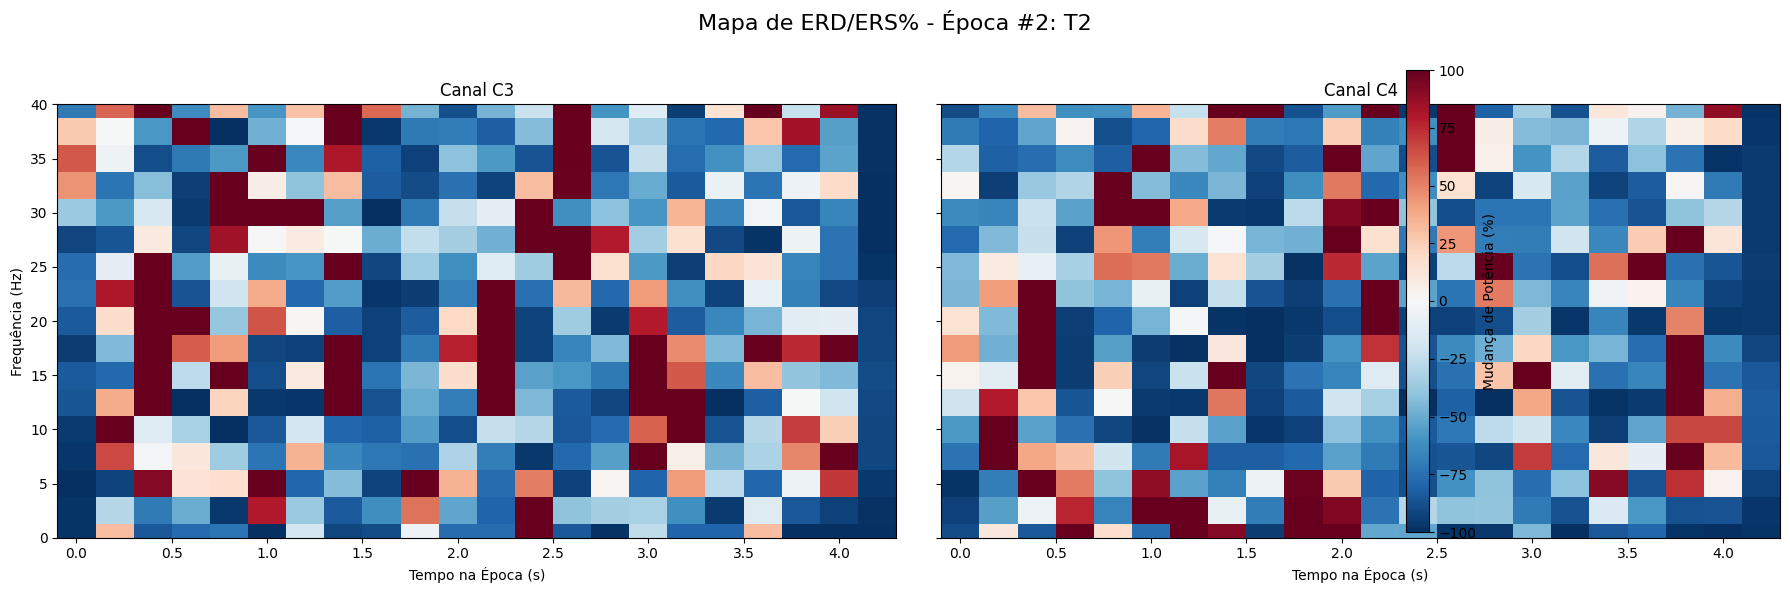

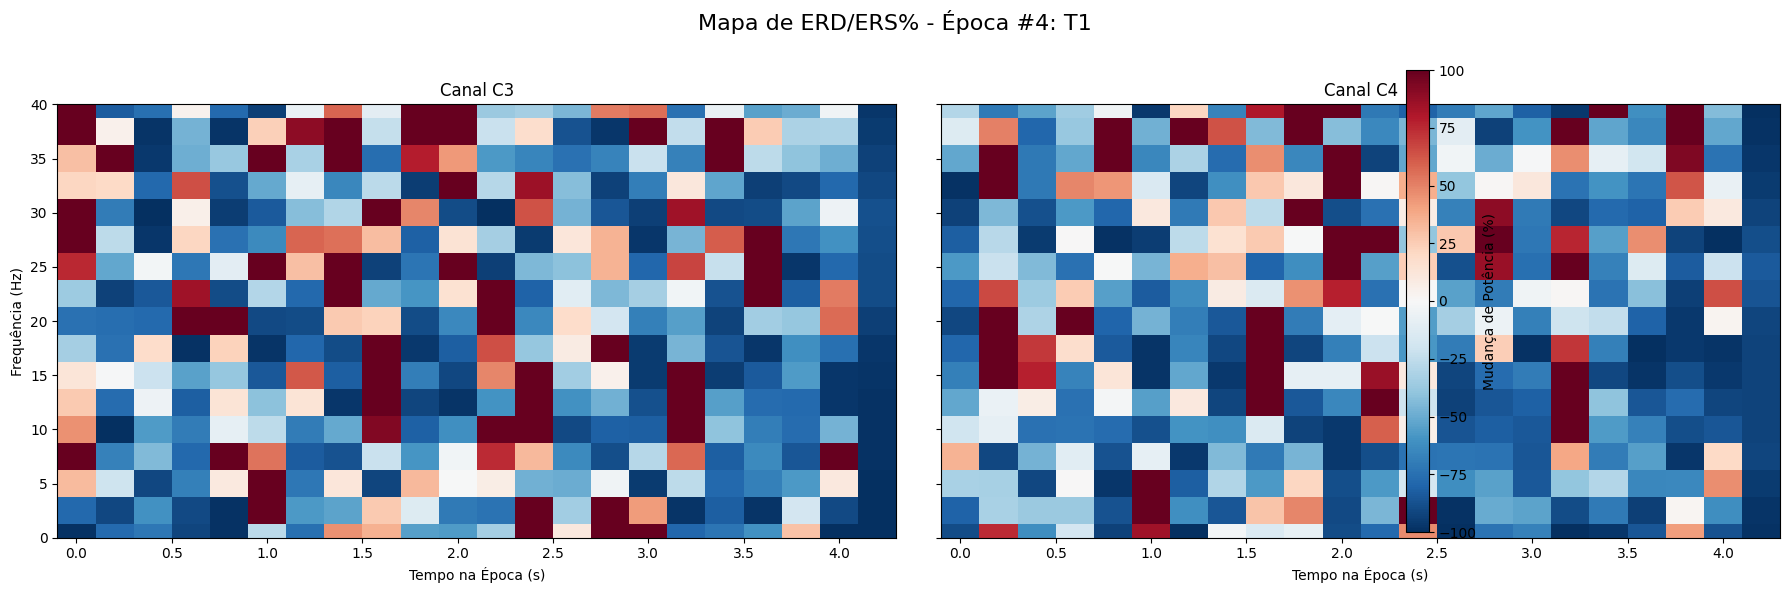

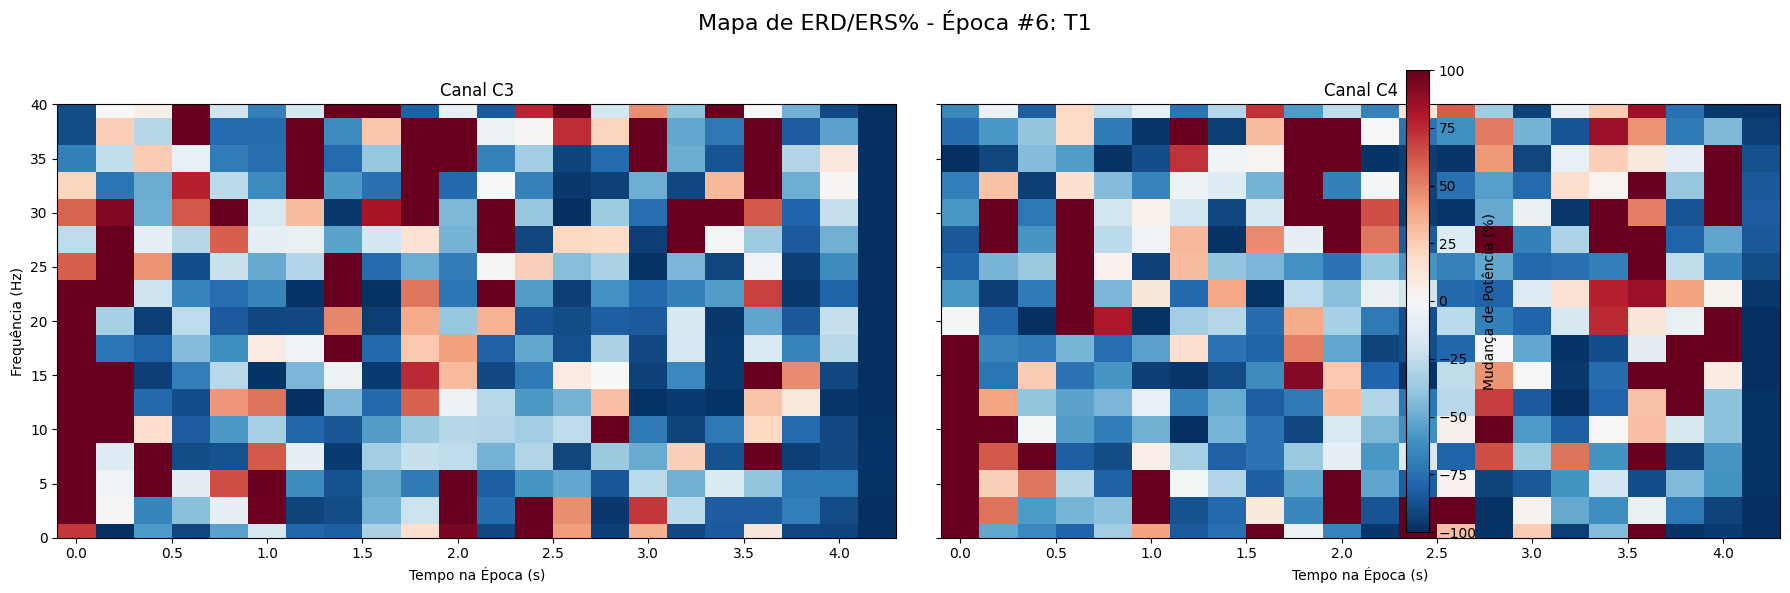

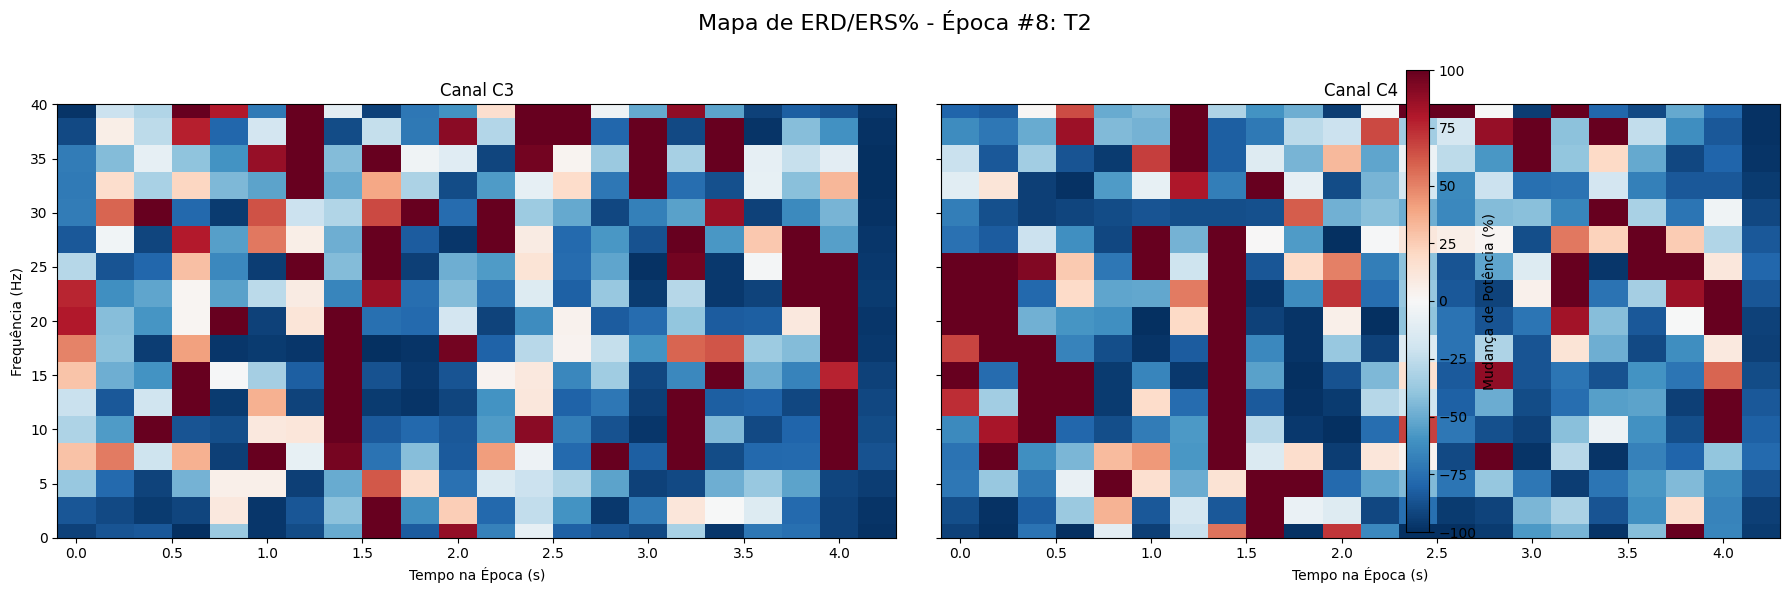

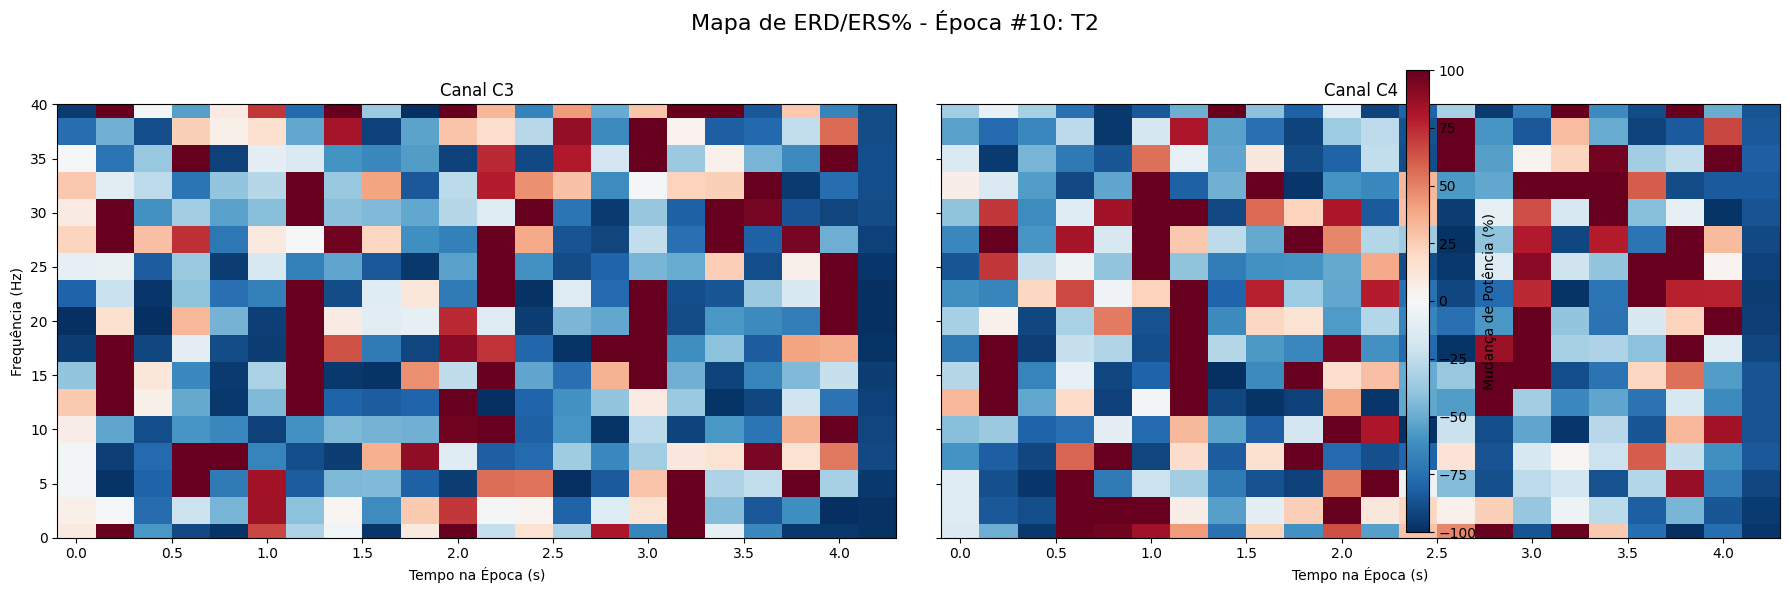

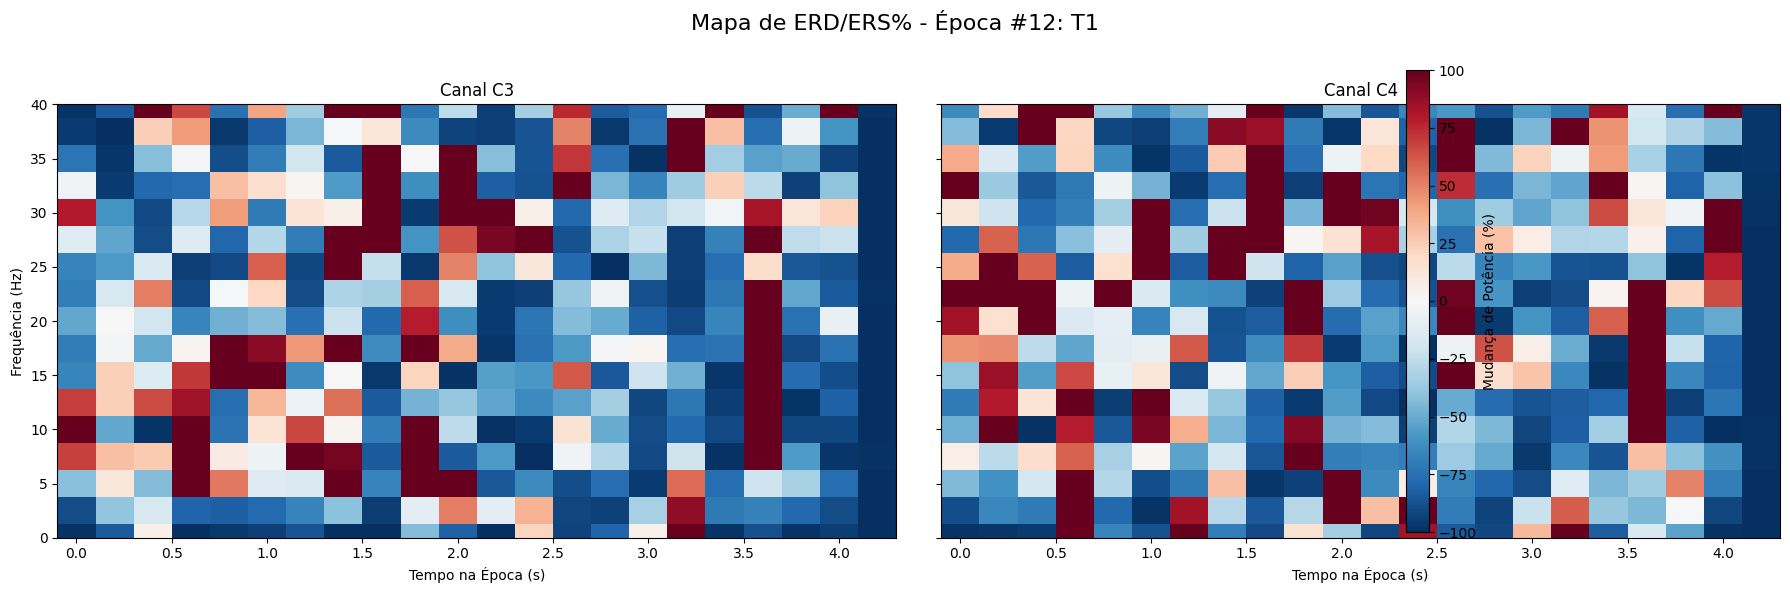

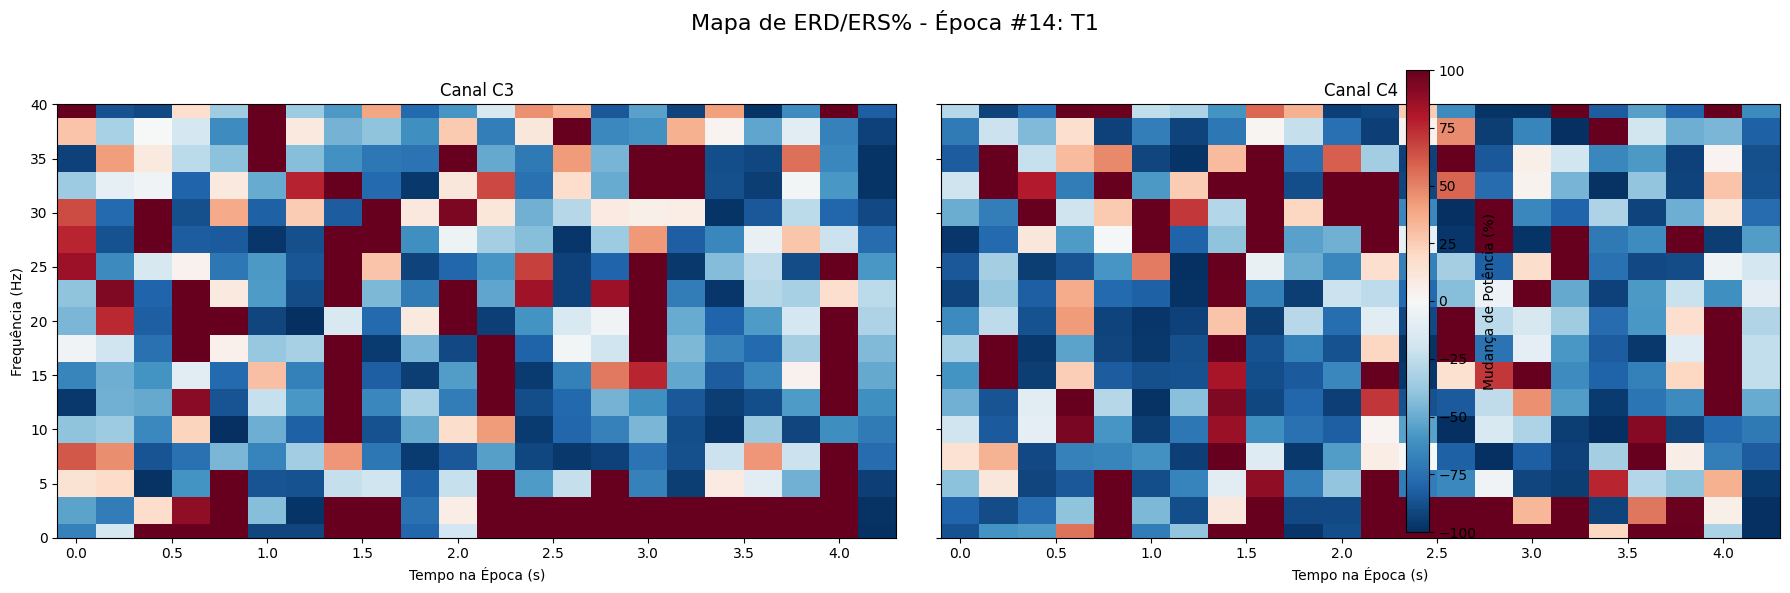

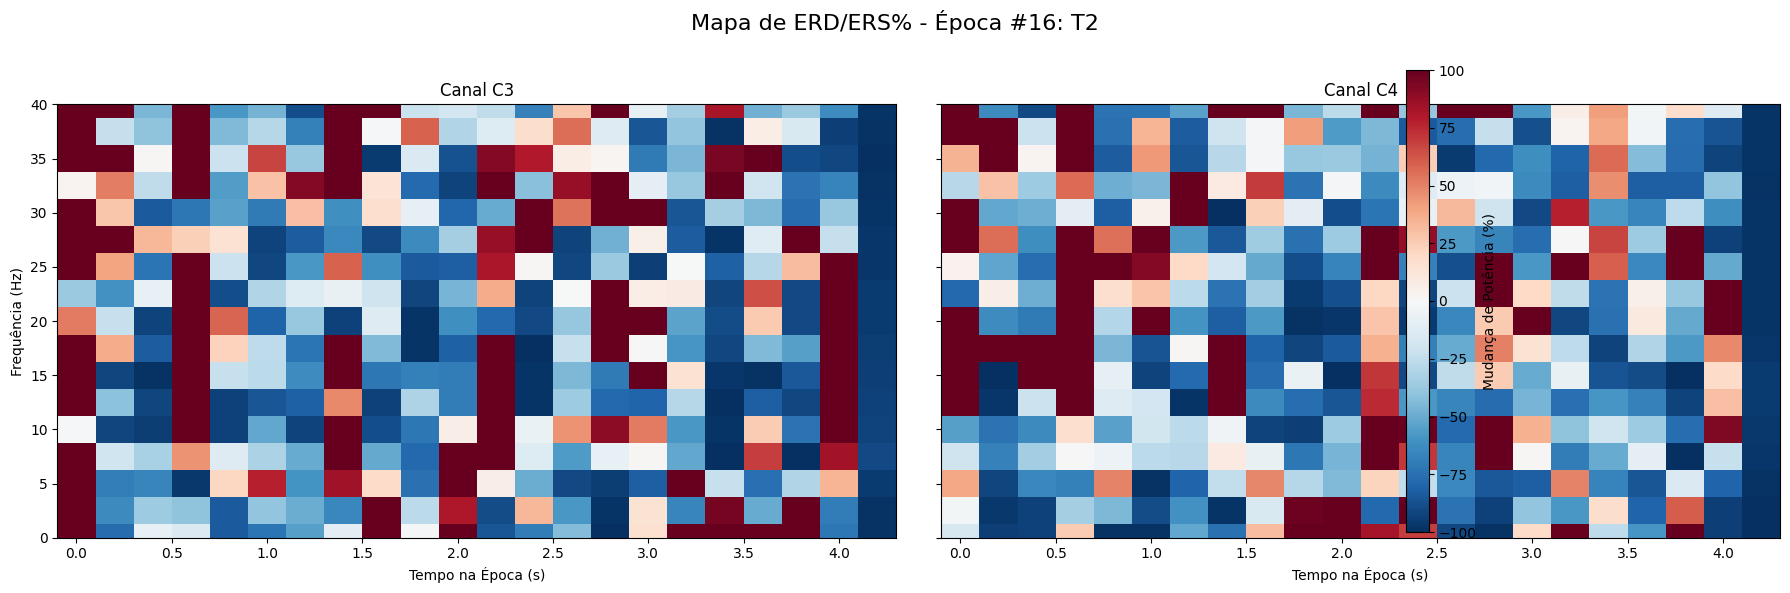

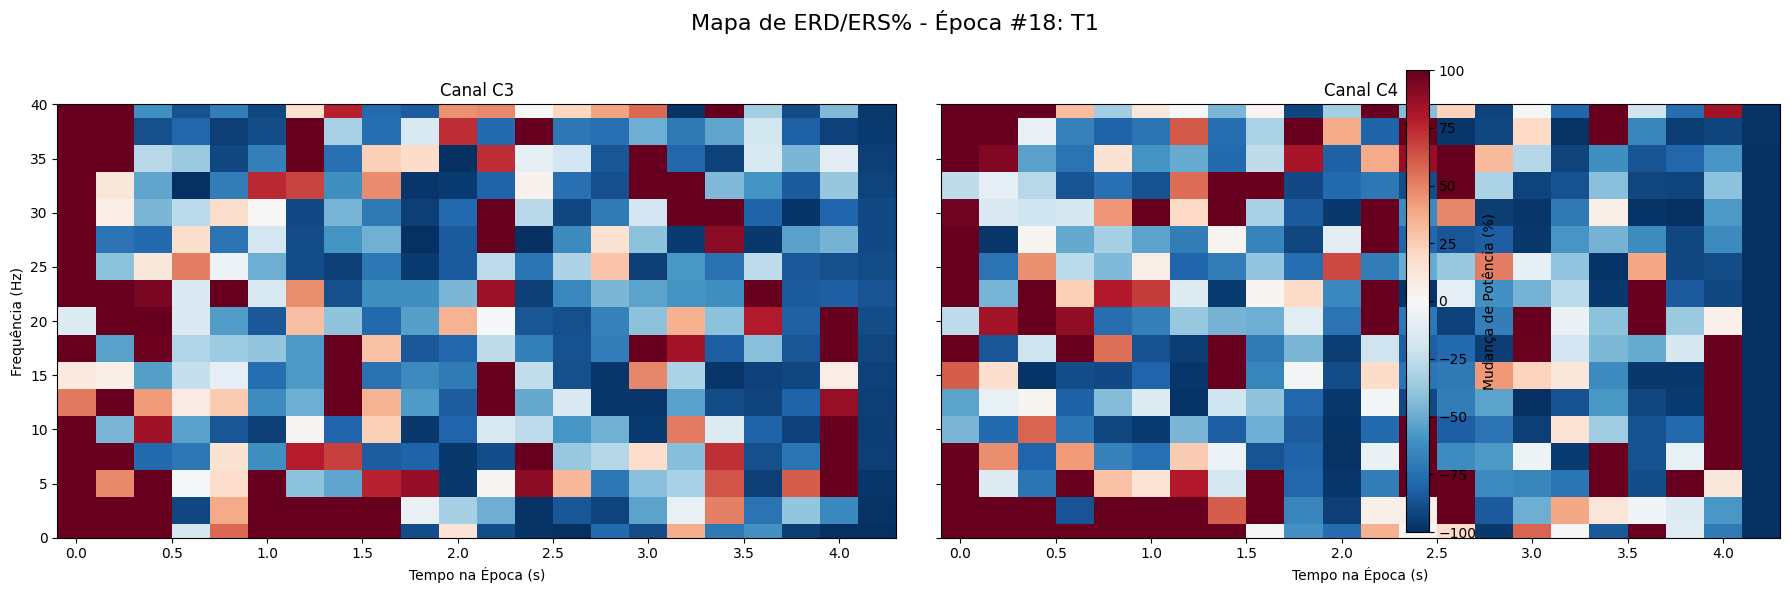

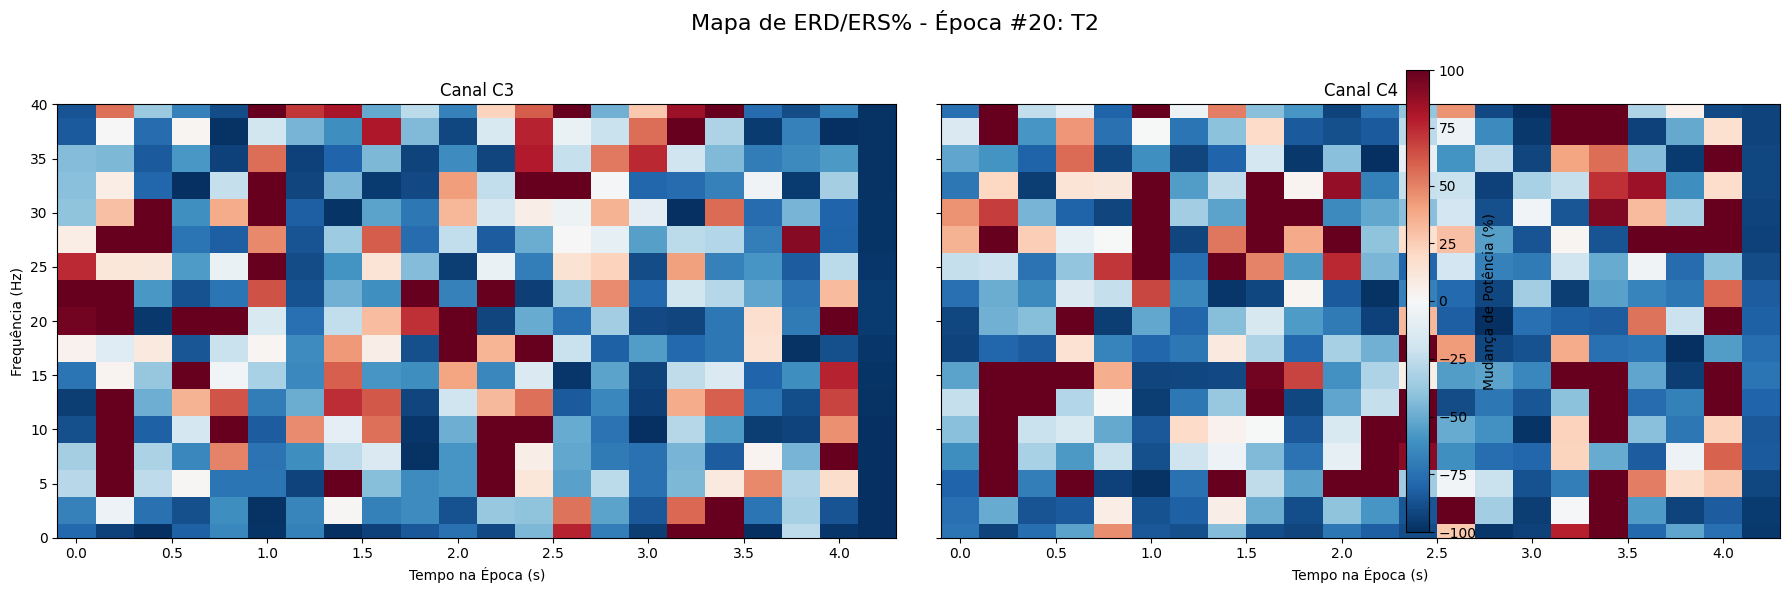

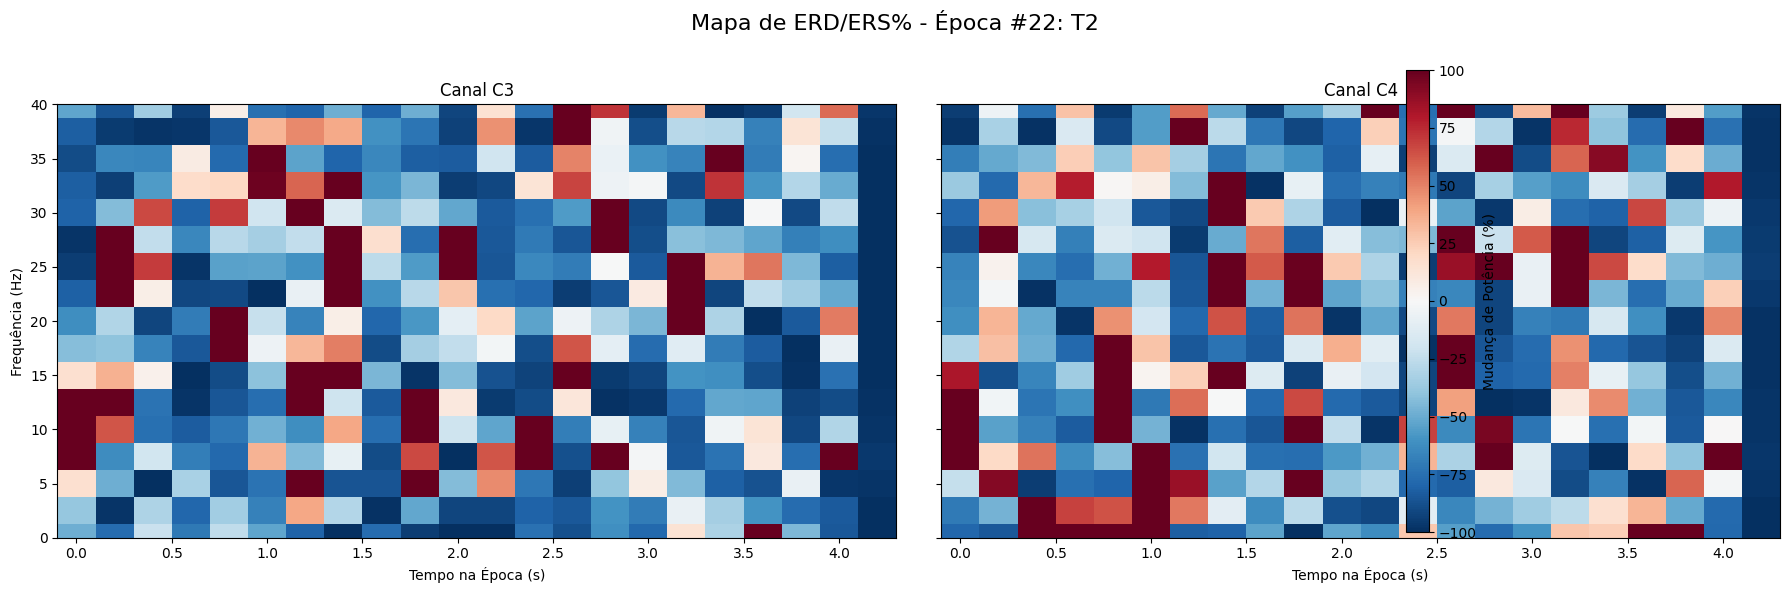

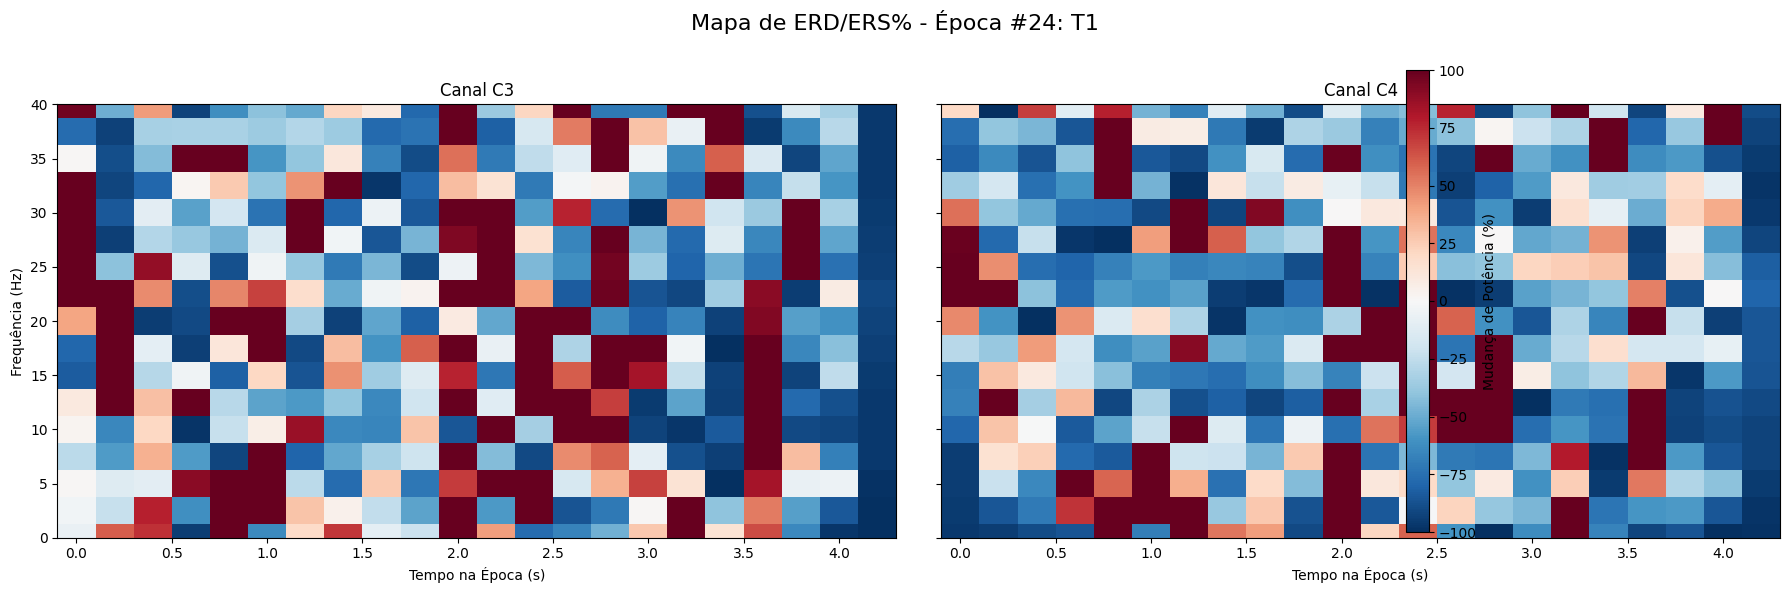

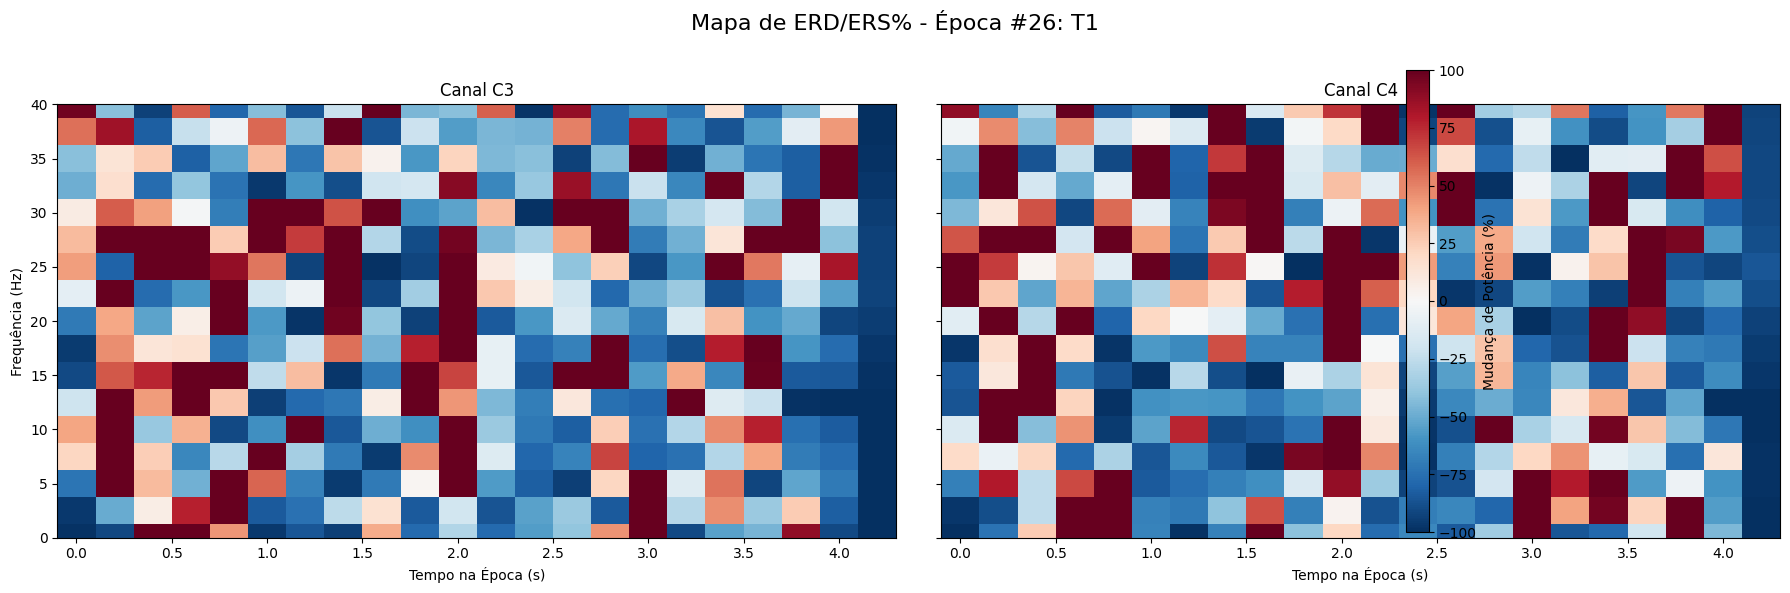

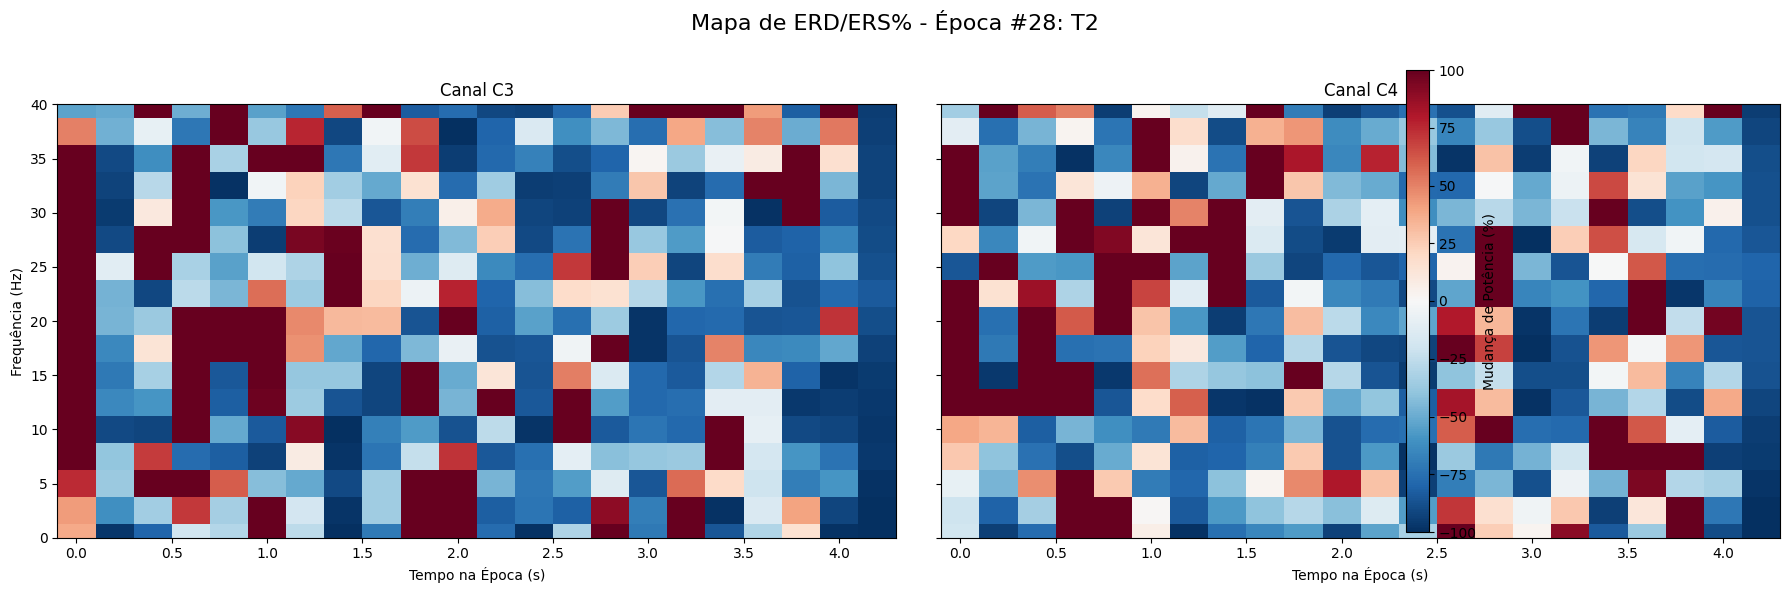

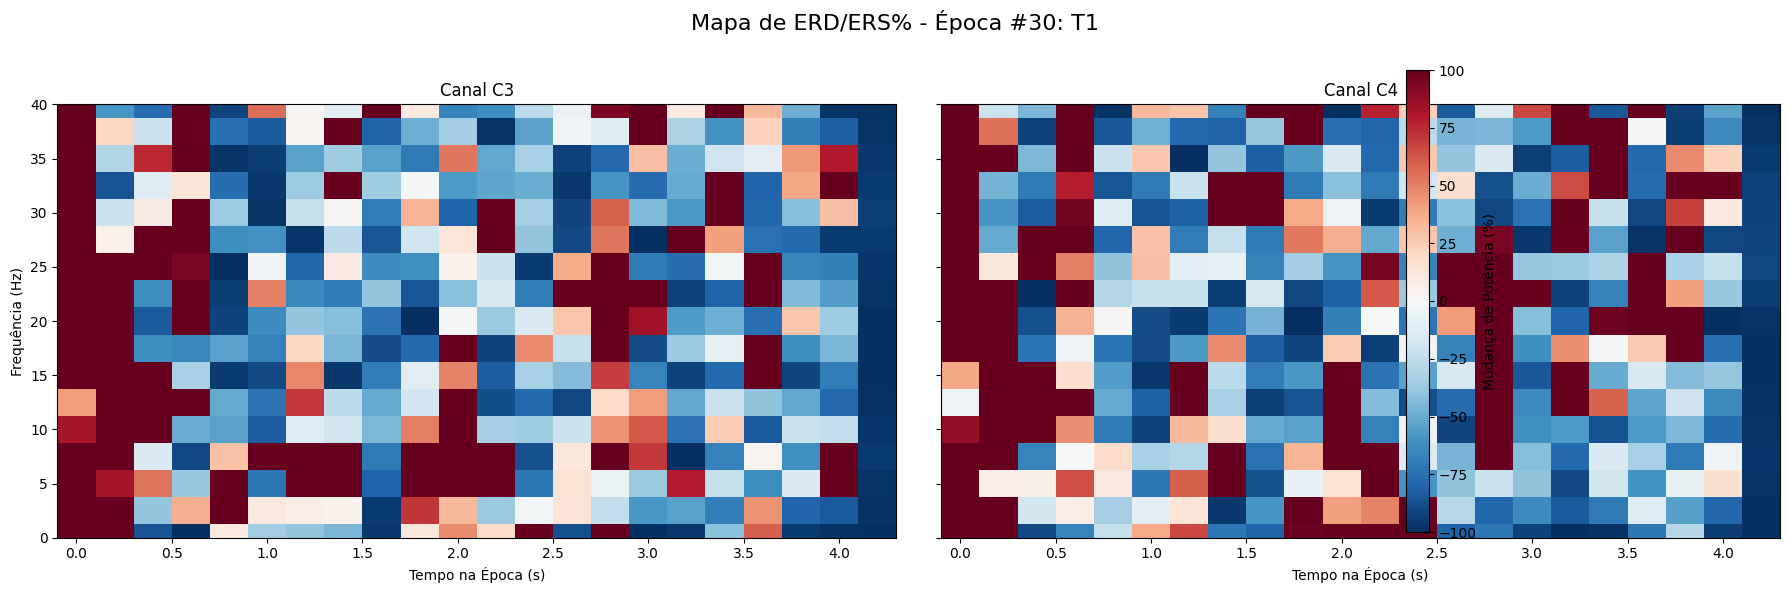

In [6]:
import os
import numpy as np
import matplotlib.pyplot as plt
from scipy.signal import stft
from pyedflib import highlevel
from tqdm import tqdm # Para adicionar uma barra de progresso

# --- 1. CONFIGURAÇÕES E CARREGAMENTO DE DADOS ---

FILE_PATH = os.path.join('data', 'physionet_data', 'S001', 'S001R03.edf')
WINDOW_DURATION_MS = 400

try:
    signals, signal_headers, header = highlevel.read_edf(FILE_PATH)
    annotations = header['annotations']
    fs = signal_headers[0]['sample_frequency']
    channel_names = [h['label'] for h in signal_headers]
    c3_idx = channel_names.index('C3..')
    c4_idx = channel_names.index('C4..')
    signal_c3 = signals[c3_idx, :]
    signal_c4 = signals[c4_idx, :]
except Exception as e:
    print(f"Erro ao carregar o arquivo: {e}")
    exit()

# Parâmetros da STFT
nperseg = int((WINDOW_DURATION_MS / 1000.0) * fs)
noverlap = nperseg // 2

# --- 2. FASE 1: CÁLCULO DA LINHA DE BASE (BASELINE) MÉDIA ---

print("Fase 1: Calculando a linha de base média a partir das épocas T0...")

baseline_spectrograms_c3 = []
baseline_spectrograms_c4 = []
min_time_bins = float('inf') # Para garantir que todos os espectrogramas tenham o mesmo tamanho

# Primeiro passo para encontrar o tamanho mínimo de espectrograma
for onset, duration, description in annotations:
    if description == 'T0':
        start_sample, end_sample = int(onset * fs), int((onset + duration) * fs)
        if end_sample > len(signal_c3): continue
        epoch_c3 = signal_c3[start_sample:end_sample]
        _, _, Zxx_c3 = stft(epoch_c3, fs=fs, nperseg=nperseg, noverlap=noverlap)
        min_time_bins = min(min_time_bins, Zxx_c3.shape[1])

# Segundo passo para coletar os espectrogramas, truncando para o tamanho mínimo
for onset, duration, description in tqdm(annotations, desc="Processando T0"):
    if description == 'T0':
        start_sample, end_sample = int(onset * fs), int((onset + duration) * fs)
        if end_sample > len(signal_c3): continue
        
        epoch_c3 = signal_c3[start_sample:end_sample]
        epoch_c4 = signal_c4[start_sample:end_sample]
        
        _, _, Zxx_c3 = stft(epoch_c3, fs=fs, nperseg=nperseg, noverlap=noverlap)
        _, _, Zxx_c4 = stft(epoch_c4, fs=fs, nperseg=nperseg, noverlap=noverlap)
        
        # Armazena a potência, garantindo que todos tenham a mesma largura (nº de time bins)
        baseline_spectrograms_c3.append(np.abs(Zxx_c3[:, :min_time_bins])**2)
        baseline_spectrograms_c4.append(np.abs(Zxx_c4[:, :min_time_bins])**2)

# Calcula a média de todas as potências da linha de base
# Adicionamos um valor muito pequeno (epsilon) para evitar divisão por zero mais tarde
epsilon = 1e-12
mean_baseline_c3 = np.mean(np.array(baseline_spectrograms_c3), axis=0) + epsilon
mean_baseline_c4 = np.mean(np.array(baseline_spectrograms_c4), axis=0) + epsilon

print("Linha de base calculada com sucesso.")


# --- 3. FASE 2: CÁLCULO E PLOTAGEM DO ERD/ERS% PARA ÉPOCAS ATIVAS ---

print("\nFase 2: Calculando e plotando mapas de ERD/ERS% para épocas T1 e T2...")

for i, (onset, duration, description) in enumerate(annotations):
    if description in ['T1', 'T2']:
        start_sample, end_sample = int(onset * fs), int((onset + duration) * fs)
        if end_sample > len(signal_c3): continue

        epoch_c3 = signal_c3[start_sample:end_sample]
        epoch_c4 = signal_c4[start_sample:end_sample]
        
        f, t, Zxx_c3 = stft(epoch_c3, fs=fs, nperseg=nperseg, noverlap=noverlap)
        _, _, Zxx_c4 = stft(epoch_c4, fs=fs, nperseg=nperseg, noverlap=noverlap)

        # Calcula a potência da época ativa
        active_power_c3 = np.abs(Zxx_c3[:, :min_time_bins])**2
        active_power_c4 = np.abs(Zxx_c4[:, :min_time_bins])**2
        
        # --- APLICA A FÓRMULA ERD/ERS% ---
        erd_map_c3 = ((active_power_c3 - mean_baseline_c3) / mean_baseline_c3) * 100
        erd_map_c4 = ((active_power_c4 - mean_baseline_c4) / mean_baseline_c4) * 100
        
        # --- Plotagem ---
        fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(18, 6), sharey=True)
        fig.suptitle(f'Mapa de ERD/ERS% - Época #{i+1}: {description}', fontsize=16)
        
        # Definir limites de cor simétricos para uma visualização clara
        # Ex: -100% a 100% de mudança. Ajuste se necessário.
        color_limit = 100
        
        # Plot do mapa de ERD/ERS para C3
        # Usamos um colormap divergente. 'RdBu_r' (Red-Blue reversed) é ótimo: Vermelho=aumento, Azul=diminuição
        im1 = ax1.pcolormesh(t[:min_time_bins], f, erd_map_c3, cmap='RdBu_r', vmin=-color_limit, vmax=color_limit)
        ax1.set_title('Canal C3')
        ax1.set_ylabel('Frequência (Hz)')
        ax1.set_xlabel('Tempo na Época (s)')
        ax1.set_ylim(0, 40)

        # Plot do mapa de ERD/ERS para C4
        im2 = ax2.pcolormesh(t[:min_time_bins], f, erd_map_c4, cmap='RdBu_r', vmin=-color_limit, vmax=color_limit)
        ax2.set_title('Canal C4')
        ax2.set_xlabel('Tempo na Época (s)')
        
        fig.colorbar(im2, ax=[ax1, ax2], label='Mudança de Potência (%)')
        plt.tight_layout(rect=[0, 0, 1, 0.95])
        plt.show()

In [8]:
import numpy as np
import os
import cv2
import shutil
from pathlib import Path
from sklearn.model_selection import train_test_split
from tqdm import tqdm
from pyedflib import EdfReader
from scipy.signal import stft, butter, filtfilt

# --- Funções ---
def bandpass_filter(data, lowcut, highcut, fs, order=4):
    nyquist = 0.5 * fs; low = lowcut / nyquist; high = highcut / nyquist
    b, a = butter(order, [low, high], btype='band'); return filtfilt(b, a, data)

def notch_filter(data, notch_freq, fs, quality=30):
    nyquist = 0.5 * fs; freq = notch_freq / nyquist
    b, a = butter(2, [freq - 0.5/quality, freq + 0.5/quality], btype='bandstop'); return filtfilt(b, a, data)

def save_difference_map_as_image(diff_map, output_path):
    """Normaliza o mapa de diferença e o salva como uma imagem em tons de cinza."""
    normalized_map = cv2.normalize(diff_map, None, 0, 255, cv2.NORM_MINMAX, dtype=cv2.CV_8U)
    bgr_image = cv2.cvtColor(normalized_map, cv2.COLOR_GRAY2BGR)
    cv2.imwrite(output_path, bgr_image)

# --- Configurações Globais ---
pasta_raiz_sujeitos = Path('data/physionet_data')
all_subject_ids = [f'S{i:03d}' for i in range(1, 110)]
registros = ['R03', 'R07', 'R11']

# ### MUDANÇA PRINCIPAL AQUI ###
# Incluindo a classe T0 (descanso) no dicionário de eventos.
event_dict = {'T0': 'rest', 'T1': 'left', 'T2': 'right'}

fs = 160
WINDOW_DURATION_MS = 400
nperseg = int((WINDOW_DURATION_MS / 1000.0) * fs)
noverlap = nperseg // 2

# --- FASE 1: DETERMINAR A RESOLUÇÃO PADRÃO (LARGURA MÍNIMA) ---
print("Fase 1: Calculando a resolução mínima para padronização...")
min_time_bins = float('inf')

for subject_id in tqdm(all_subject_ids, desc="Analisando durações"):
    subject_folder_path = pasta_raiz_sujeitos / subject_id
    if not subject_folder_path.is_dir(): continue

    for registro in registros:
        edf_file = next(subject_folder_path.glob(f'*{registro}.edf'), None)
        if not edf_file: continue
        try:
            reader = EdfReader(str(edf_file))
            annotations = reader.readAnnotations()
            reader.close()
            
            for duration in annotations[1]:
                num_samples = int(duration * fs)
                if num_samples < nperseg: continue
                t_len = np.floor((num_samples - noverlap) / (nperseg - noverlap)).astype(int)
                min_time_bins = min(min_time_bins, t_len)
        except Exception:
            continue

print(f"Resolução padronizada: Largura será fixada em {min_time_bins} pixels de tempo.")

# --- FASE 2: GERAR E SALVAR IMAGENS PADRONIZADAS ---
base_output_data_dir = f"eeg_diff_images_3class_{WINDOW_DURATION_MS}ms"
if os.path.exists(base_output_data_dir): shutil.rmtree(base_output_data_dir)
train_subjects, val_subjects = train_test_split(all_subject_ids, test_size=0.2, random_state=42)

# O loop abaixo irá criar automaticamente a pasta 'rest' por causa da mudança no event_dict
for split in ['train', 'val']:
    for class_name in event_dict.values():
        os.makedirs(os.path.join(base_output_data_dir, split, class_name), exist_ok=True)

print(f"\nFase 2: Iniciando a geração de imagens para 3 classes no dataset '{base_output_data_dir}'...")

for subject_id in tqdm(all_subject_ids, desc="Processando Sujeitos"):
    subject_folder_path = pasta_raiz_sujeitos / subject_id
    if not subject_folder_path.is_dir(): continue

    split_folder = 'train' if subject_id in train_subjects else 'val'
    
    for registro in registros:
        edf_file = next(subject_folder_path.glob(f'*{registro}.edf'), None)
        if not edf_file: continue

        try:
            reader = EdfReader(str(edf_file))
            channel_labels = reader.getSignalLabels()
            c3_idx = channel_labels.index('C3..')
            c4_idx = channel_labels.index('C4..')
            
            c3_signal = notch_filter(bandpass_filter(reader.readSignal(c3_idx), 0.5, 40, fs), 60, fs)
            c4_signal = notch_filter(bandpass_filter(reader.readSignal(c4_idx), 0.5, 40, fs), 60, fs)
            
            annotations = reader.readAnnotations()
            reader.close()
            
            for i, (onset, duration, description) in enumerate(zip(annotations[0], annotations[1], annotations[2])):
                # Este 'if' agora incluirá 'T0' por causa da mudança no event_dict
                if description in event_dict:
                    class_name = event_dict[description]
                    
                    start_sample = int(onset * fs)
                    end_sample = start_sample + int(duration * fs)
                    
                    if end_sample > len(c3_signal) or (end_sample - start_sample) < nperseg: continue
                    
                    epoch_c3 = c3_signal[start_sample:end_sample]
                    epoch_c4 = c4_signal[start_sample:end_sample]
                    
                    _, _, Zxx_c3 = stft(epoch_c3, fs=fs, nperseg=nperseg, noverlap=noverlap)
                    _, _, Zxx_c4 = stft(epoch_c4, fs=fs, nperseg=nperseg, noverlap=noverlap)
                    
                    power_c3 = np.abs(Zxx_c3)**2
                    power_c4 = np.abs(Zxx_c4)**2
                    power_difference = power_c4 - power_c3
                    
                    power_difference_std = power_difference[:, :min_time_bins]
                    
                    base_filename = f"{subject_id}_{registro}_epoch_{i}.png"
                    output_path = os.path.join(base_output_data_dir, split_folder, class_name, base_filename)
                    save_difference_map_as_image(power_difference_std, output_path)

        except Exception as e:
            print(f"Erro no arquivo {edf_file.name} para o sujeito {subject_id}: {e}")
            if 'reader' in locals() and reader.isOpen(): reader.close()
            continue

print(f"\nProcessamento concluído. Dataset com 3 classes salvo em: '{base_output_data_dir}'")

Fase 1: Calculando a resolução mínima para padronização...


Analisando durações:   0%|          | 0/109 [00:00<?, ?it/s]

Analisando durações: 100%|██████████| 109/109 [00:00<00:00, 275.21it/s]


Resolução padronizada: Largura será fixada em 5 pixels de tempo.

Fase 2: Iniciando a geração de imagens para 3 classes no dataset 'eeg_diff_images_3class_400ms'...


Processando Sujeitos: 100%|██████████| 109/109 [00:08<00:00, 13.03it/s]


Processamento concluído. Dataset com 3 classes salvo em: 'eeg_diff_images_3class_400ms'


In [3]:
import numpy as np
import os
import cv2
import shutil
from pathlib import Path
from sklearn.model_selection import train_test_split
from tqdm import tqdm
from pyedflib import EdfReader
from scipy.signal import stft, butter, filtfilt

# --- Funções ---
def bandpass_filter(data, lowcut, highcut, fs, order=4):
    nyquist = 0.5 * fs; low = lowcut / nyquist; high = highcut / nyquist
    b, a = butter(order, [low, high], btype='band'); return filtfilt(b, a, data)

def notch_filter(data, notch_freq, fs, quality=30):
    nyquist = 0.5 * fs; freq = notch_freq / nyquist
    b, a = butter(2, [freq - 0.5/quality, freq + 0.5/quality], btype='bandstop'); return filtfilt(b, a, data)

# ### FUNÇÃO MODIFICADA ###
def save_difference_map_as_image(diff_map, output_path, new_width=32):
    """
    Normaliza o mapa de diferença, o redimensiona para uma nova largura
    e o salva como uma imagem em tons de cinza.
    """
    # Normaliza o mapa para 0-255
    normalized_map = cv2.normalize(diff_map, None, 0, 255, cv2.NORM_MINMAX, dtype=cv2.CV_8U)
    
    # Converte para 3 canais BGR para poder redimensionar e salvar
    bgr_image = cv2.cvtColor(normalized_map, cv2.COLOR_GRAY2BGR)
    
    # --- NOVA LINHA PARA REDIMENSIONAR A IMAGEM ---
    # `h` é a altura original (ex: 33), `new_width` é a nova largura (ex: 32)
    h, _, _ = bgr_image.shape
    resized_image = cv2.resize(bgr_image, (new_width, h), interpolation=cv2.INTER_NEAREST)
    # ------------------------------------------------
    
    cv2.imwrite(output_path, resized_image)

# --- Configurações Globais ---
# (Mantenha as mesmas configurações do script anterior)
pasta_raiz_sujeitos = Path('data/physionet_data')
all_subject_ids = [f'S{i:03d}' for i in range(1, 110)]
registros = ['R03', 'R07', 'R11']
event_dict = {'T0': 'rest', 'T1': 'left', 'T2': 'right'}
fs = 160
# Você provavelmente está usando uma janela maior para ter apenas 5 pixels de largura,
# vamos usar 800ms como exemplo.
WINDOW_DURATION_MS = 800
nperseg = int((WINDOW_DURATION_MS / 1000.0) * fs)
noverlap = nperseg // 2

# --- FASE 1: DETERMINAR A RESOLUÇÃO PADRÃO (LARGURA MÍNIMA) ---
print("Fase 1: Calculando a resolução mínima para padronização...")
min_time_bins = float('inf')

for subject_id in tqdm(all_subject_ids, desc="Analisando durações"):
    subject_folder_path = pasta_raiz_sujeitos / subject_id
    if not subject_folder_path.is_dir(): continue

    for registro in registros:
        edf_file = next(subject_folder_path.glob(f'*{registro}.edf'), None)
        if not edf_file: continue
        try:
            reader = EdfReader(str(edf_file))
            annotations = reader.readAnnotations()
            reader.close()
            
            for duration in annotations[1]:
                num_samples = int(duration * fs)
                if num_samples < nperseg: continue
                t_len = np.floor((num_samples - noverlap) / (nperseg - noverlap)).astype(int)
                min_time_bins = min(min_time_bins, t_len)
        except Exception:
            continue
min_time_bins = 5 # O valor que você encontrou

print(f"Largura mínima original encontrada: {min_time_bins} pixels. As imagens serão redimensionadas.")

# --- FASE 2: GERAR E SALVAR IMAGENS PADRONIZADAS ---
base_output_data_dir = f"eeg_diff_images_resized_{WINDOW_DURATION_MS}ms"
if os.path.exists(base_output_data_dir): shutil.rmtree(base_output_data_dir)
train_subjects, val_subjects = train_test_split(all_subject_ids, test_size=0.2, random_state=42)
for split in ['train', 'val']:
    for class_name in event_dict.values():
        os.makedirs(os.path.join(base_output_data_dir, split, class_name), exist_ok=True)

print(f"\nFase 2: Iniciando a geração de imagens redimensionadas para o dataset '{base_output_data_dir}'...")

for subject_id in tqdm(all_subject_ids, desc="Processando Sujeitos"):
    # ... (O loop principal permanece o mesmo, a mudança está na chamada da função de salvar) ...
    # O código abaixo é a parte relevante dentro do loop principal
    subject_folder_path = pasta_raiz_sujeitos / subject_id
    if not subject_folder_path.is_dir(): continue
    split_folder = 'train' if subject_id in train_subjects else 'val'
    for registro in registros:
        edf_file = next(subject_folder_path.glob(f'*{registro}.edf'), None)
        if not edf_file: continue
        try:
            reader = EdfReader(str(edf_file))
            channel_labels = reader.getSignalLabels()
            c3_idx = channel_labels.index('C3..')
            c4_idx = channel_labels.index('C4..')
            c3_signal = notch_filter(bandpass_filter(reader.readSignal(c3_idx), 0.5, 40, fs), 60, fs)
            c4_signal = notch_filter(bandpass_filter(reader.readSignal(c4_idx), 0.5, 40, fs), 60, fs)
            annotations = reader.readAnnotations()
            reader.close()
            for i, (onset, duration, description) in enumerate(zip(annotations[0], annotations[1], annotations[2])):
                if description in event_dict:
                    class_name = event_dict[description]
                    start_sample = int(onset * fs)
                    end_sample = start_sample + int(duration * fs)
                    if end_sample > len(c3_signal) or (end_sample - start_sample) < nperseg: continue
                    epoch_c3 = c3_signal[start_sample:end_sample]
                    epoch_c4 = c4_signal[start_sample:end_sample]
                    _, _, Zxx_c3 = stft(epoch_c3, fs=fs, nperseg=nperseg, noverlap=noverlap)
                    _, _, Zxx_c4 = stft(epoch_c4, fs=fs, nperseg=nperseg, noverlap=noverlap)
                    power_difference = np.abs(Zxx_c4)**2 - np.abs(Zxx_c3)**2
                    power_difference_std = power_difference[:, :min_time_bins]
                    base_filename = f"{subject_id}_{registro}_epoch_{i}.png"
                    output_path = os.path.join(base_output_data_dir, split_folder, class_name, base_filename)
                    # A chamada para a função agora irá redimensionar a imagem antes de salvar
                    save_difference_map_as_image(power_difference_std, output_path)
        except Exception as e:
            if 'reader' in locals() and reader.isOpen(): reader.close()
            continue
print(f"\nProcessamento concluído.")

Fase 1: Calculando a resolução mínima para padronização...


Analisando durações: 100%|██████████| 109/109 [00:00<00:00, 257.56it/s]


Largura mínima original encontrada: 5 pixels. As imagens serão redimensionadas.

Fase 2: Iniciando a geração de imagens redimensionadas para o dataset 'eeg_diff_images_resized_800ms'...


Processando Sujeitos: 100%|██████████| 109/109 [00:11<00:00,  9.66it/s]


Processamento concluído.
